# Links

* **[The Ultra-Scale Playbook](https://huggingface.co/spaces/nanotron/ultrascale-playbook)** —
  the memory widget in "Memory usage in Transformers". For a Llama 3 8B preset it shows how
  parameters, gradients, optimizer state and activations change with sequence length,
  micro-batch, ZeRO stage and tensor parallelism. Sections 01 and 04 derive the same formulas and
  check them on a small model.
* **[Perfetto](https://ui.perfetto.dev/)** — a trace viewer. Section 01 writes
  `out/01_step_trace.json`, a Chrome-format trace of one training step recorded with
  `torch.profiler`. Opened in Perfetto (or `chrome://tracing`), it shows the step as a timeline:
  forward, backward, optimizer, and the time of each operator. Zoom with `W`/`S`, pan with `A`/`D`.
* **[CS336 lecture 7](https://cs336.stanford.edu/lectures/?trace=lecture_07)** — Stanford's
  executable lecture on parallelism. The `benchmarking` part runs all-reduce and reduce-scatter
  on real GPUs and reports the achieved bandwidth. Section 03 implements the same collectives on
  Python lists and counts the bytes.

---

# 01 — anatomy of one training step

One training step has three phases: forward, backward and `optimizer.step()`. Their cost is
measured in FLOPs, in bytes held in memory, and in wall-clock time. We take a small GPT
(pre-norm, SwiGLU, small enough to run on a CPU in seconds) and measure all three with the
tools used on real runs: `torch.profiler`, `FlopCounterMode`, and autograd's saved-tensor hooks.

Contents:

1. **backward is two matmuls per linear layer**, so it costs 2× forward, and the `6ND` rule
   for training FLOPs is `2ND + 4ND`;
2. **where the time goes** in one step, from a profiler trace;
3. **how the shares change with scale** (model width, batch size) on this CPU and on an A100;
4. **what autograd keeps** between forward and backward, and why this, not the optimizer,
   dominates GPU memory at scale; **recompute** trades those bytes for ~⅓ more FLOPs;
5. **the optimizer step**: a few element-wise passes over 16 bytes per parameter.

Runtime ~40 s on CPU. Dependencies: `torch`, `matplotlib`.

In [1]:
from __future__ import annotations

import json
import os
import shutil
import statistics
import sys
import tempfile
import time
from collections import defaultdict
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.profiler import ProfilerActivity, profile, record_function
from torch.utils.checkpoint import checkpoint
from torch.utils.flop_counter import FlopCounterMode

if hasattr(sys.stdout, "reconfigure"):
    sys.stdout.reconfigure(encoding="utf-8", errors="replace")
torch.manual_seed(0)
torch.set_num_threads(max(1, (os.cpu_count() or 2) // 2))       # half the cores; idempotent when sections run in one kernel

OUT = Path("out")
OUT.mkdir(exist_ok=True)

## 1. The model

Pre-norm blocks, parameter-free RMSNorm, causal attention through `scaled_dot_product_attention`,
SwiGLU MLP, untied embeddings: a standard modern decoder at small size.

In [2]:
@dataclass
class Cfg:
    vocab: int = 512
    block: int = 64
    n_layer: int = 4
    n_head: int = 4
    n_embd: int = 128
    d_ff: int = 384          # 3·d for SwiGLU keeps ~8d² parameters per MLP, as in the frontier stacks


def norm(x):
    return F.rms_norm(x, (x.size(-1),))


class Attention(nn.Module):
    def __init__(self, c: Cfg):
        super().__init__()
        self.n_head, self.dh = c.n_head, c.n_embd // c.n_head
        self.qkv = nn.Linear(c.n_embd, 3 * c.n_embd, bias=False)
        self.o = nn.Linear(c.n_embd, c.n_embd, bias=False)

    def forward(self, x):
        B, T, C = x.shape
        q, k, v = self.qkv(x).view(B, T, 3, self.n_head, self.dh).permute(2, 0, 3, 1, 4)
        y = F.scaled_dot_product_attention(q, k, v, is_causal=True)
        return self.o(y.transpose(1, 2).reshape(B, T, C))


class MLP(nn.Module):
    def __init__(self, c: Cfg):
        super().__init__()
        self.gate = nn.Linear(c.n_embd, c.d_ff, bias=False)
        self.up = nn.Linear(c.n_embd, c.d_ff, bias=False)
        self.down = nn.Linear(c.d_ff, c.n_embd, bias=False)

    def forward(self, x):
        return self.down(F.silu(self.gate(x)) * self.up(x))


class Block(nn.Module):
    def __init__(self, c: Cfg):
        super().__init__()
        self.attn, self.mlp = Attention(c), MLP(c)

    def forward(self, x):
        x = x + self.attn(norm(x))
        return x + self.mlp(norm(x))


class GPT(nn.Module):
    def __init__(self, c: Cfg, use_checkpoint: bool = False):
        super().__init__()
        self.c, self.use_checkpoint = c, use_checkpoint
        self.wte = nn.Embedding(c.vocab, c.n_embd)
        self.blocks = nn.ModuleList(Block(c) for _ in range(c.n_layer))
        self.head = nn.Linear(c.n_embd, c.vocab, bias=False)

    def forward(self, idx, targets=None):
        x = norm(self.wte(idx))
        for b in self.blocks:
            # recompute: forget the block's internals after forward, run the block again in backward
            x = checkpoint(b, x, use_reentrant=False) if self.use_checkpoint else b(x)
        logits = self.head(norm(x))
        if targets is None:
            return logits, None
        return logits, F.cross_entropy(logits.view(-1, self.c.vocab), targets.reshape(-1))


cfg = Cfg()
model = GPT(cfg)
B, T = 8, cfg.block
x = torch.randint(0, cfg.vocab, (B, T))
y = torch.randint(0, cfg.vocab, (B, T))

N = sum(p.numel() for p in model.parameters())
N_matmul = N - model.wte.weight.numel()   # the embedding is a lookup: it costs no FLOPs
print(f"parameters: {N / 1e6:.2f}M, of which {N_matmul / 1e6:.2f}M take part in matmuls; "
      f"batch {B}×{T} = {B * T} tokens")

parameters: 0.98M, of which 0.92M take part in matmuls; batch 8×64 = 512 tokens


## 2. Backward of one linear layer, by hand

`y = x Wᵀ` with `x: (tokens, d_in)`, `W: (d_out, d_in)`. Given `g = ∂L/∂y`, the chain rule gives
two gradients, and each is a matmul **of the same size as the forward one**:

* `∂L/∂x = g W` — needed to keep going backwards to the previous layer;
* `∂L/∂W = gᵀ x` — the gradient of the weights, which **needs `x`**. This is why `x` is kept
  from the forward pass; it is the activation memory measured in section 6.

Forward is one matmul and backward is two, hence 2ND for the forward, 4ND for the backward and
`6ND` in total.

In [3]:
lin = nn.Linear(128, 384, bias=False)
xin = torch.randn(B * T, 128, requires_grad=True)
yout = lin(xin)
g = torch.randn_like(yout)                    # pretend this is ∂L/∂y coming from the layer above
yout.backward(g)                              # autograd's answer

grad_x = g @ lin.weight                       # (tokens, d_out) @ (d_out, d_in)
grad_W = g.T @ xin.detach()                   # (d_out, tokens) @ (tokens, d_in) — needs the saved input

assert torch.allclose(grad_x, xin.grad, atol=1e-5) and torch.allclose(grad_W, lin.weight.grad, atol=1e-4)
fwd_flops = 2 * (B * T) * 128 * 384
print(f"forward: one matmul, {fwd_flops / 1e6:.1f} MFLOP; backward: two of them, {2 * fwd_flops / 1e6:.1f} MFLOP. "
      f"autograd agrees with the hand-written version.")

forward: one matmul, 50.3 MFLOP; backward: two of them, 100.7 MFLOP. autograd agrees with the hand-written version.


## 3. Counting FLOPs for the whole model

`FlopCounterMode` intercepts every matmul-like op and adds up `2·m·k·n`. We count forward
alone and forward+backward, then compare with the estimates `2·N·T` / `6·N·T`.

In [4]:
with FlopCounterMode(display=False) as fc_fwd:
    _, loss = model(x, y)
with FlopCounterMode(display=False) as fc_all:
    _, loss = model(x, y)
    loss.backward()
model.zero_grad(set_to_none=True)

flops_fwd, flops_all = fc_fwd.get_total_flops(), fc_all.get_total_flops()
flops_bwd = flops_all - flops_fwd
print(f"forward  : {flops_fwd / 1e9:.3f} GFLOP   ~ 2·N·T = {2 * N_matmul * B * T / 1e9:.3f}")
print(f"backward : {flops_bwd / 1e9:.3f} GFLOP   ~ 4·N·T = {4 * N_matmul * B * T / 1e9:.3f}   (ratio bwd/fwd = {flops_bwd / flops_fwd:.2f})")
print(f"total    : {flops_all / 1e9:.3f} GFLOP   ~ 6·N·T = {6 * N_matmul * B * T / 1e9:.3f}")

# by module, forward only — where the matmuls live
by_module = {k: sum(v.values()) for k, v in fc_fwd.get_flop_counts().items() if k != "Global"}
groups = defaultdict(int)
for name, f in by_module.items():
    if name.endswith((".qkv", ".o")):
        groups["attention projections"] += f
    elif name.endswith((".gate", ".up", ".down")):
        groups["MLP"] += f
    elif name.endswith("head"):
        groups["lm_head"] += f
# The fused attention kernel on CPU has no entry in FlopCounterMode, so QKᵀ and PV are counted
# by hand: 2·T·T·d each, per layer, per sequence. (The counter does know the CUDA kernels.)
attn_scores = cfg.n_layer * B * 4 * T * T * cfg.n_embd
groups["attention scores (QKᵀ, PV), by hand"] = attn_scores
print("\nforward FLOPs by module class:")
for k, v in sorted(groups.items(), key=lambda kv: -kv[1]):
    print(f"  {k:<40} {v / 1e6:8.1f} MFLOP  {100 * v / (flops_fwd + attn_scores):5.1f}%")

forward  : 0.940 GFLOP   ~ 2·N·T = 0.940
backward : 1.879 GFLOP   ~ 4·N·T = 1.879   (ratio bwd/fwd = 2.00)
total    : 2.819 GFLOP   ~ 6·N·T = 2.819

forward FLOPs by module class:
  MLP                                         604.0 MFLOP   60.0%
  attention projections                       268.4 MFLOP   26.7%
  lm_head                                      67.1 MFLOP    6.7%
  attention scores (QKᵀ, PV), by hand          67.1 MFLOP    6.7%


The ratio is exactly 2: every linear layer computes both gradients, because even the first
block's input needs a gradient to flow back into the embedding table. The only layer that
would break the rule is one whose input is a constant — a model fed raw features rather than
an embedding — and there the first layer skips `∂L/∂x` and the ratio dips just under 2.

The attention-score matmuls (`QKᵀ` and `PV`) are `4·T²·d` per layer per sequence and had to
be added by hand: the counter has formulas for the CUDA attention kernels but not for the
fused CPU one. At T = 64 they are negligible next to the projections; at T = 128k they dominate,
which is the reason for context parallelism. The `lm_head` line is also worth noting: with a
small `d` and a vocabulary of only 512 it is already 7% of the forward. The vocabulary costs
FLOPs, not only parameters.

## 4. Where the time goes: `torch.profiler`

The three phases are wrapped in `record_function`, so they appear as named spans in the trace.
A profile of the whole step is exported to `out/01_step_trace.json` and can be opened in
Perfetto. Then each phase is profiled separately to count its matmuls.

In [5]:
opt = torch.optim.AdamW(model.parameters(), lr=1e-3, betas=(0.9, 0.95), weight_decay=0.1)

def step():
    with record_function("forward"):
        _, loss = model(x, y)
    with record_function("backward"):
        loss.backward()
    with record_function("optimizer.step"):
        opt.step()
        opt.zero_grad(set_to_none=True)

for _ in range(3):        # warm-up: the first step pays for allocator growth and lazy init
    step()

with profile(activities=[ProfilerActivity.CPU], record_shapes=True) as prof:
    step()
tmp_trace = Path(tempfile.gettempdir()) / "01_step_trace.json"   # the exporter wants an ASCII path
prof.export_chrome_trace(str(tmp_trace))
shutil.move(tmp_trace, OUT / "01_step_trace.json")
print(f"→ {OUT / '01_step_trace.json'}  (drag it into https://ui.perfetto.dev)\n")
print(prof.key_averages().table(sort_by="self_cpu_time_total", row_limit=12,
                                max_name_column_width=48, max_shapes_column_width=0))

# FLOPs live almost entirely in matmuls; time does not. Split the step's operator time in two.
MATMUL_OPS = ("aten::mm", "aten::addmm", "aten::bmm", "aten::baddbmm", "aten::_scaled_dot_product_flash_attention_for_cpu")
ops = [e for e in prof.key_averages() if e.key.startswith("aten::")]
t_mm = sum(e.self_cpu_time_total for e in ops if e.key in MATMUL_OPS)
t_all = sum(e.self_cpu_time_total for e in ops)
print(f"matmul-like operators: ~100% of the FLOPs, {100 * t_mm / t_all:.0f}% of the operator time; "
      f"everything else (norms, SiLU, adds, casts, copies, the optimizer's element-wise passes): {100 * (1 - t_mm / t_all):.0f}%")

→ out\01_step_trace.json  (drag it into https://ui.perfetto.dev)



------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                            Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg    # of Calls  
------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                        aten::mm        30.11%      13.547ms        30.18%      13.576ms     215.490us            63  
                                        backward         5.73%       2.579ms        56.88%      25.587ms      25.587ms             1  
                                       aten::mul         4.83%       2.174ms         5.49%       2.468ms      30.102us            82  
                       Optimizer.step#AdamW.step         4.45%       2.001ms        15.31%       6.888ms       6.888ms             1  
                                         forward       

In [6]:
def profile_phase(setup, fn, repeats=5):
    """Median over repeats of: total CPU time of the phase, and how many matmul kernels it ran.
    `setup` runs un-profiled before each repeat (a backward needs a fresh forward, and so on)."""
    times, mms = [], None
    for _ in range(repeats):
        state = setup()
        with profile(activities=[ProfilerActivity.CPU]) as p:
            fn(state)
        ka = p.key_averages()
        times.append(sum(e.self_cpu_time_total for e in ka) / 1e3)
        mms = sum(e.count for e in ka if e.key in ("aten::mm", "aten::addmm", "aten::bmm", "aten::baddbmm"))
    times.sort()
    return times[len(times) // 2], mms


def run_forward():
    return model(x, y)[1]

def run_backward(loss):
    loss.backward()

def forward_and_backward():
    model(x, y)[1].backward()

def run_opt(_):
    opt.step(); opt.zero_grad(set_to_none=True)

phase_ms, phase_mm = {}, {}
phase_ms["forward"], phase_mm["forward"] = profile_phase(lambda: None, lambda _: run_forward())
phase_ms["backward"], phase_mm["backward"] = profile_phase(run_forward, run_backward)
phase_ms["optimizer.step"], phase_mm["optimizer.step"] = profile_phase(forward_and_backward, run_opt)
total_ms = sum(phase_ms.values())
print(f"{'phase':<16}{'ms':>8}{'share':>8}{'matmul kernels':>16}")
for k in phase_ms:
    print(f"{k:<16}{phase_ms[k]:8.1f}{100 * phase_ms[k] / total_ms:7.0f}%{phase_mm[k]:16d}")

phase                 ms   share  matmul kernels
forward              9.8     27%              21
backward            20.2     56%              42
optimizer.step       6.2     17%               0


In the matmul column, backward runs about twice as many matmul kernels as forward: the
two-gradients-per-layer rule from section 2, counted by the profiler. In the time column, the
optimizer step takes a noticeable share on this CPU: AdamW is a dozen element-wise passes over
every parameter, each memory-bound. The line printed under the operator table shows the same
thing: matmuls do essentially all the FLOPs, but a large share of the time goes to operators
that do almost no arithmetic.

⚠ Absolute milliseconds on a laptop CPU do not reproduce. The ratios do: matmuls bwd/fwd ≈ 2,
and the optimizer step is memory-bound.

A published profile of one Llama 2 7B pre-training step (Zhang et al., *Dissecting the Runtime
Performance of the Training, Fine-tuning, and Inference of LLMs*, 2023, Table V) gives forward
14%, backward 48%, optimizer 37%. These shares depend on the configuration, as the next section
shows.

## 5. The same step at other sizes

Forward and backward do work proportional to **parameters × tokens**; AdamW's step does work
proportional to **parameters only**, independent of the batch. So the optimizer's share should
fall roughly as `1 / tokens per step`, while changing the width `d` should scale all three
phases together (parameters grow as `d²` in all of them). Below: three widths × three batch
sizes, the same model otherwise, each phase timed separately.

In [7]:
SWEEP_WIDTHS, SWEEP_BATCHES, SWEEP_REPEATS = (64, 128, 256), (1, 4, 16), 5


def time_phases(d: int, batch: int) -> dict:
    """Median wall-clock of forward, backward and optimizer.step for one (width, batch)."""
    torch.manual_seed(0)
    c = Cfg(n_embd=d, d_ff=3 * d)
    m = GPT(c)
    o = torch.optim.AdamW(m.parameters(), lr=1e-3, betas=(0.9, 0.95), weight_decay=0.1)
    xb, yb = torch.randint(0, c.vocab, (batch, c.block)), torch.randint(0, c.vocab, (batch, c.block))
    t = {"forward": [], "backward": [], "optimizer.step": []}
    for i in range(2 + SWEEP_REPEATS):                # two warm-up steps, then the measured ones
        t0 = time.perf_counter(); _, loss = m(xb, yb)
        t1 = time.perf_counter(); loss.backward()
        t2 = time.perf_counter(); o.step(); o.zero_grad(set_to_none=True)
        t3 = time.perf_counter()
        if i >= 2:
            for k, dt in zip(t, (t1 - t0, t2 - t1, t3 - t2)):
                t[k].append(1e3 * dt)
    return {"params": sum(p.numel() for p in m.parameters()), "tokens": batch * c.block,
            **{k: statistics.median(v) for k, v in t.items()}}


sweep_cpu = {(d, b): time_phases(d, b) for d in SWEEP_WIDTHS for b in SWEEP_BATCHES}
print(f"{'d':>4}{'batch':>6}{'params':>9}{'tokens':>8}{'fwd ms':>9}{'bwd ms':>9}{'step ms':>9}{'step share':>12}{'bwd/fwd':>9}")
for (d, b), r in sweep_cpu.items():
    total = r["forward"] + r["backward"] + r["optimizer.step"]
    print(f"{d:>4}{b:>6}{r['params'] / 1e6:>8.2f}M{r['tokens']:>8}{r['forward']:>9.1f}{r['backward']:>9.1f}"
          f"{r['optimizer.step']:>9.1f}{100 * r['optimizer.step'] / total:>11.0f}%{r['backward'] / r['forward']:>9.2f}")

   d batch   params  tokens   fwd ms   bwd ms  step ms  step share  bwd/fwd
  64     1    0.28M      64      3.0      4.8      3.6         32%     1.57
  64     4    0.28M     256      4.5      7.6      3.4         22%     1.68
  64    16    0.28M    1024      7.9     15.1      3.4         13%     1.91
 128     1    0.98M      64      2.9      6.3      5.0         35%     2.18
 128     4    0.98M     256      6.6     12.7      5.1         21%     1.92
 128    16    0.98M    1024     16.7     30.7      6.1         11%     1.84
 256     1    3.67M      64      6.3     10.7      7.0         29%     1.69
 256     4    3.67M     256     12.9     27.0      7.2         15%     2.09
 256    16    3.67M    1024     42.6     80.1     12.2          9%     1.88


The same sweep on a real GPU, recorded in advance with `gpu/step_sweep.py`: an A100, eight
layers, sequence 512, vocabulary 32k, fp32 master weights with bf16 autocast, every phase timed
with CUDA events (a host timer would stop before the GPU finishes: kernel launches are
asynchronous). The optimizer step is timed twice — PyTorch's default AdamW on CUDA
(`foreach`: one kernel per operation, applied to the whole list of tensors) and `fused=True`
(one kernel for the entire update). MFU is model FLOPs per second over the chip's bf16 peak.

In [8]:
gpu_sweep_path = OUT / "gpu_step_sweep.json"
gpu_sweep = json.loads(gpu_sweep_path.read_text()) if gpu_sweep_path.exists() else None
if gpu_sweep:
    e = gpu_sweep["env"]
    print(f"{e['gpu']}, torch {e['torch']}; {gpu_sweep['layers']} layers, seq {gpu_sweep['seq']}, "
          f"vocab {gpu_sweep['vocab']}, {gpu_sweep['precision']}\n")
    print(f"{'d':>5}{'batch':>6}{'params':>9}{'fwd ms':>8}{'bwd ms':>8}{'step foreach':>13}{'fused':>7}"
          f"{'step share (fused)':>20}{'bwd/fwd':>9}{'MFU':>6}")
    for r in gpu_sweep["rows"]:
        if r.get("oom"):
            print(f"{r['d']:>5}{r['batch']:>6}   out of memory")
            continue
        share = r["step_fused_ms"] / (r["forward_ms"] + r["backward_ms"] + r["step_fused_ms"])
        print(f"{r['d']:>5}{r['batch']:>6}{r['params'] / 1e6:>8.0f}M{r['forward_ms']:>8.1f}{r['backward_ms']:>8.1f}"
              f"{r['step_foreach_ms']:>13.2f}{r['step_fused_ms']:>7.2f}{100 * share:>19.1f}%"
              f"{r['bwd_over_fwd']:>9.2f}{100 * r['mfu']:>5.0f}%")
else:
    print("no out/gpu_step_sweep.json — run gpu/step_sweep.py on a machine with a GPU")

NVIDIA A100-PCIE-40GB, torch 2.11.0+cu128; 8 layers, seq 512, vocab 32768, fp32 master weights, bf16 autocast

    d batch   params  fwd ms  bwd ms step foreach  fused  step share (fused)  bwd/fwd   MFU
  256     1      23M     8.3    12.4         2.45   1.32                6.0%     1.50    1%
  256     2      23M     7.8    12.1         2.42   1.02                4.9%     1.55    2%
  256     4      23M     8.5    12.7         2.29   1.01                4.5%     1.49    3%
  256     8      23M    10.9    12.6         2.23   1.24                5.0%     1.16    5%
  256    16      23M    12.2    12.8         1.55   1.01                3.9%     1.05   10%
  256    32      23M    18.2    23.2         1.55   1.41                3.3%     1.27   12%
  256    64      23M    31.1    44.7         1.56   1.40                1.8%     1.43   13%
  512     1      58M     8.4    12.5         4.45   2.10                9.1%     1.49    2%
  512     2      58M     8.5    12.4         4.59   2.00     

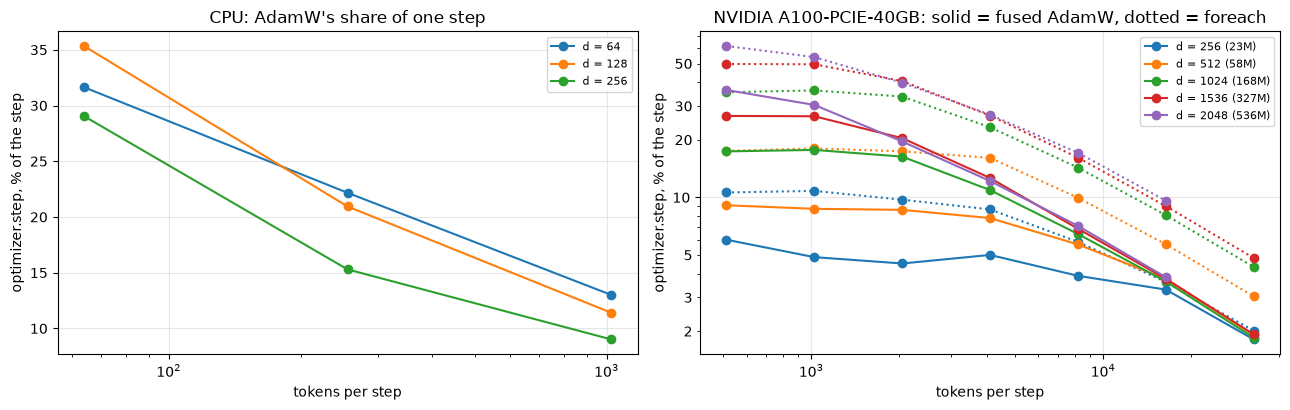

→ out\01_step_sweep.png


In [9]:
fig, ax = plt.subplots(1, 2 if gpu_sweep else 1, figsize=(13 if gpu_sweep else 6.5, 4.2), squeeze=False)
ax = ax[0]
for d in SWEEP_WIDTHS:
    pts = [(r["tokens"], 100 * r["optimizer.step"] / (r["forward"] + r["backward"] + r["optimizer.step"]))
           for (dd, _), r in sweep_cpu.items() if dd == d]
    ax[0].plot(*zip(*pts), "o-", label=f"d = {d}")
ax[0].set_xscale("log"); ax[0].set_xlabel("tokens per step"); ax[0].set_ylabel("optimizer.step, % of the step")
ax[0].set_title("CPU: AdamW's share of one step"); ax[0].legend(fontsize=8)
if gpu_sweep:
    rows = [r for r in gpu_sweep["rows"] if not r.get("oom")]
    for i, d in enumerate(sorted({r["d"] for r in rows})):
        rr = sorted((r for r in rows if r["d"] == d), key=lambda r: r["tokens"])
        tok = [r["tokens"] for r in rr]
        for key, ls in (("step_fused_ms", "-"), ("step_foreach_ms", ":")):
            share = [100 * r[key] / (r["forward_ms"] + r["backward_ms"] + r[key]) for r in rr]
            ax[1].plot(tok, share, ls, marker="o", color=f"C{i}",
                       label=f"d = {d} ({rr[0]['params'] / 1e6:.0f}M)" if key == "step_fused_ms" else None)
    ax[1].set_xscale("log"); ax[1].set_yscale("log")
    ax[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:g}"))
    ax[1].yaxis.set_minor_formatter(plt.FuncFormatter(lambda v, _: f"{v:g}" if v in (2, 3, 5, 20, 30, 50) else ""))
    ax[1].set_xlabel("tokens per step"); ax[1].set_ylabel("optimizer.step, % of the step")
    ax[1].set_title(f"{gpu_sweep['env']['gpu']}: solid = fused AdamW, dotted = foreach"); ax[1].legend(fontsize=8)
for a in ax:
    a.grid(alpha=.3)
fig.tight_layout(); fig.savefig(OUT / "01_step_sweep.png", dpi=140)
plt.show()
print(f"→ {OUT / '01_step_sweep.png'}")

In the CPU table at `d = 128`, the optimizer's share falls from about a third of the step at 64
tokens to about a tenth at 1 024: forward and backward grow with the batch, the optimizer step
does not. The ratio bwd/fwd is below 2 at the smallest sizes because every operator has a fixed
overhead, paid similarly in forward and backward, which dilutes the 2× in FLOPs.

The GPU table is the same experiment on hardware with fast matmuls. Observations:

* **at a small batch, forward time does not depend on model size.** At batch 1 and 2, forward
  takes about 8 ms whether the model has 23M parameters or 536M. This is the overhead of
  launching a few hundred kernels from Python: the GPU finishes each kernel faster than the next
  one arrives. MFU of the small models there is in single digits. It grows with batch and width,
  up to 40–47% for the two widest models, which is the argument for large per-GPU batches;
* **at a small batch, width determines the optimizer's share.** In the launch-bound regime
  forward and backward stay constant, while the optimizer step, which reads and writes every
  parameter, grows with the model: at batch 1 the fused step is 6% of the step at `d = 256` and
  36% at `d = 2048`, and 60% with the default foreach implementation. A large model with a small
  micro-batch per GPU is one way to get the optimizer at a third of the step, as in the published
  profile above;
* **foreach against fused.** The default AdamW launches one kernel per operation over the list
  of tensors; the fused one launches a single kernel. The fused one is 2.5–2.8× faster at every
  width. It is bounded by memory bandwidth: it reads parameter, gradient, `m` and `v` (16 bytes
  per parameter) and writes three of them back (12 bytes), so on an A100 with ~1.5 TB/s a 536M
  model cannot step faster than 536M × 28 B / 1.5 TB/s ≈ 10 ms. The measured time is 12.5 ms,
  about 80% of the memory bandwidth. Only moving fewer bytes would make it much faster;
* **once the GPU is busy, the share falls as `1/tokens`.** At 32k tokens it is 2–4% at every
  width, and at the millions of tokens per step of a real run it is negligible, as long as the
  optimizer step is element-wise.

## 6. What autograd keeps: the saved tensors

Every op whose backward needs one of its inputs asks autograd to save it. `saved_tensors_hooks`
shows each tensor as it is saved. We tag each with the block it came from, skip the parameters
(they are in memory anyway), and add up the bytes. This is the "activations" bar of the memory
widget in the Ultra-Scale Playbook, measured instead of computed from a formula.

In [10]:
def measure_saved(m: GPT):
    param_ptrs = {p.untyped_storage().data_ptr() for p in m.parameters()}
    saved = defaultdict(int)
    seen_storages = set()          # the same tensor saved by three ops (q, k, v all save the normed x) is one allocation
    current = ["embedding/head/loss"]
    hooks = []
    for i, b in enumerate(m.blocks):
        hooks.append(b.register_forward_pre_hook(lambda mod, inp, i=i: current.__setitem__(0, f"block {i}")))
        hooks.append(b.register_forward_hook(lambda mod, inp, out: current.__setitem__(0, "embedding/head/loss")))

    def pack(t):
        st = t.untyped_storage()
        key = st.data_ptr()
        if key not in param_ptrs and key not in seen_storages:
            seen_storages.add(key)
            saved[current[0]] += st.nbytes()
        return t

    with torch.autograd.graph.saved_tensors_hooks(pack, lambda t: t):
        _, loss = m(x, y)
    loss.backward()
    m.zero_grad(set_to_none=True)
    for h in hooks:
        h.remove()
    return dict(saved)


saved_store = measure_saved(model)
model_ckpt = GPT(cfg, use_checkpoint=True)
model_ckpt.load_state_dict(model.state_dict())
saved_ckpt = measure_saved(model_ckpt)

tokens = B * T
print(f"{'where':<22}{'store everything':>18}{'checkpoint blocks':>20}")
for k in saved_store:
    print(f"{k:<22}{saved_store[k] / 1024:14.0f} KiB{saved_ckpt.get(k, 0) / 1024:16.0f} KiB")
tot_s, tot_c = sum(saved_store.values()), sum(saved_ckpt.values())
print(f"{'total':<22}{tot_s / 1024:14.0f} KiB{tot_c / 1024:16.0f} KiB")
print(f"\nper token: {tot_s / tokens:.0f} B stored vs {tot_c / tokens:.0f} B with checkpointing; "
      f"per token per block: {saved_store['block 0'] / tokens:.0f} B = {saved_store['block 0'] / tokens / cfg.n_embd / 4:.1f} × d floats (fp32)")

with FlopCounterMode(display=False) as fc_ckpt:
    _, loss = model_ckpt(x, y)
    loss.backward()
model_ckpt.zero_grad(set_to_none=True)
print(f"FLOPs with checkpointing: {fc_ckpt.get_total_flops() / flops_all:.2f}× the plain step "
      f"(the forward of every block runs twice: 6N → 8N per token)")

where                   store everything   checkpoint blocks
embedding/head/loss             1804 KiB            2828 KiB
block 0                         5132 KiB               0 KiB
block 1                         5132 KiB               0 KiB
block 2                         5132 KiB               0 KiB
block 3                         5132 KiB               0 KiB
total                          22332 KiB            2828 KiB

per token: 44664 B stored vs 5656 B with checkpointing; per token per block: 10264 B = 20.0 × d floats (fp32)
FLOPs with checkpointing: 1.24× the plain step (the forward of every block runs twice: 6N → 8N per token)


**20·d floats per token per block.** The count: the stream entering the first norm and its
normalized copy that `q`, `k`, `v` all read (2·d); `q`, `k`, `v` themselves (3·d); the attention
output that `o` will need (d); the stream and its normalized copy again for the MLP (2·d);
`gate` and `up` outputs (2 × 3·d); `silu(gate)` and the product that feeds `down` (2 × 3·d).
Twenty `d` gives 80·d bytes per token per block in fp32 and 40·d in bf16. Megatron's `34·s·b·h`
is the same kind of count for a GELU MLP with one hidden tensor of `4d`, where SwiGLU keeps four
of `3d`. Either way it is per block, times `L`, and **the number of parameters does not enter
it**. Activations scale with `b·s·L·d`, and `b` and `s` are chosen by the user. This is why,
once the optimizer state is sharded, activations are the largest item in memory on a large run
(section 04 computes it for 7B).

**Checkpointing keeps only the block input**, `d` per token instead of `20·d`, and pays by
running the forward of every block again during backward: 6N becomes 8N, +33%. Selective
recompute (drop only the tensors that are cheap to recompute, keep the matmul outputs) is in
between. FlashAttention applies the same idea to the `T×T` score matrix, which is never saved.

## 7. The optimizer's bytes

After one step, AdamW holds two fp32 buffers per parameter. With the parameter and its
gradient that is 16 bytes per parameter, and 12 of them belong to the optimizer.

In [11]:
state_bytes = sum(t.numel() * t.element_size() for s in opt.state.values() for t in s.values() if torch.is_tensor(t))
param_bytes = sum(p.numel() * p.element_size() for p in model.parameters())
_, loss = model(x, y); loss.backward()
grad_bytes = sum(p.grad.numel() * p.grad.element_size() for p in model.parameters())
model.zero_grad(set_to_none=True)
print(f"per parameter: params {param_bytes / N:.0f} B + grads {grad_bytes / N:.0f} B + Adam state {state_bytes / N:.0f} B "
      f"= {(param_bytes + grad_bytes + state_bytes) / N:.0f} B")
print(f"the same model's activations at batch {B}×{T}: {tot_s / N:.0f} B per parameter — "
      f"at this tiny batch they already outweigh the optimizer")

per parameter: params 4 B + grads 4 B + Adam state 8 B = 16 B
the same model's activations at batch 8×64: 23 B per parameter — at this tiny batch they already outweigh the optimizer


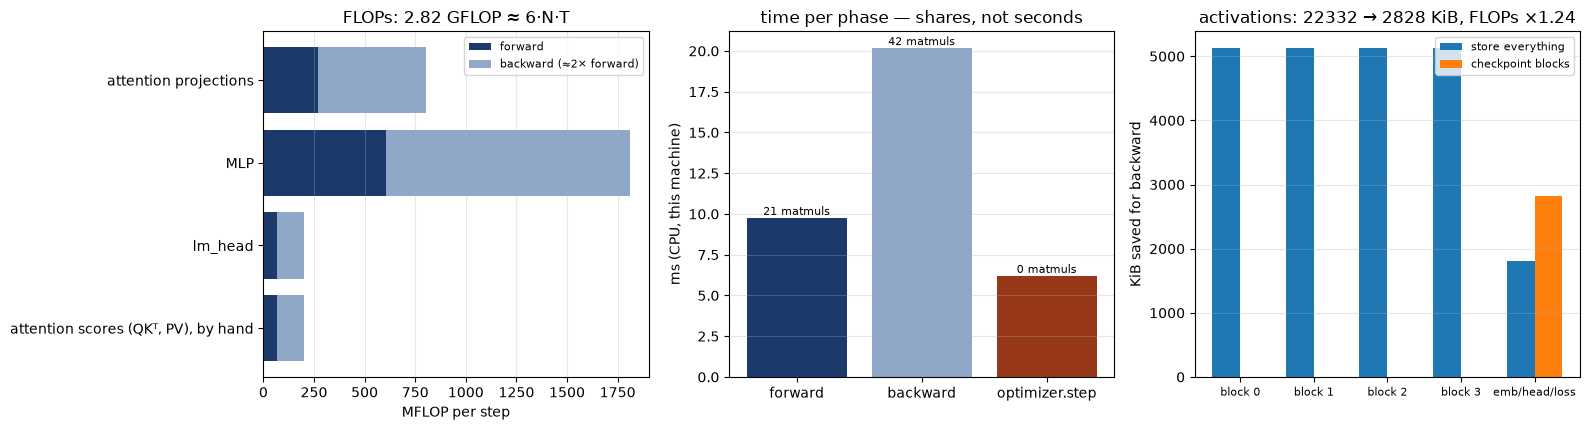

→ out\01_step_anatomy.png


In [12]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.4))
# (a) FLOPs: forward by class, backward as 2× on top
names = list(groups)
vals = [groups[k] / 1e6 for k in names]
ax[0].barh(names, vals, color="#1b3a6b", label="forward")
ax[0].barh(names, [2 * v for v in vals], left=vals, color="#8fa8c8", label="backward (≈2× forward)")
ax[0].set_xlabel("MFLOP per step"); ax[0].set_title(f"FLOPs: {flops_all / 1e9:.2f} GFLOP ≈ 6·N·T"); ax[0].legend(fontsize=8)
ax[0].invert_yaxis()
# (b) time by phase
ax[1].bar(list(phase_ms), list(phase_ms.values()), color=["#1b3a6b", "#8fa8c8", "#963817"])
for i, k in enumerate(phase_ms):
    ax[1].text(i, phase_ms[k], f"{phase_mm[k]} matmuls", ha="center", va="bottom", fontsize=8)
ax[1].set_ylabel("ms (CPU, this machine)"); ax[1].set_title("time per phase — shares, not seconds")
# (c) saved bytes per block
labels = [k for k in saved_store if k.startswith("block")] + ["embedding/head/loss"]
xs = range(len(labels)); w = 0.38
ax[2].bar([i - w / 2 for i in xs], [saved_store[k] / 1024 for k in labels], w, label="store everything")
ax[2].bar([i + w / 2 for i in xs], [saved_ckpt.get(k, 0) / 1024 for k in labels], w, label="checkpoint blocks")
ax[2].set_xticks(list(xs)); ax[2].set_xticklabels([l.replace("embedding/head/loss", "emb/head/loss") for l in labels], fontsize=8)
ax[2].set_ylabel("KiB saved for backward"); ax[2].set_title(f"activations: {tot_s / 1024:.0f} → {tot_c / 1024:.0f} KiB, FLOPs ×{fc_ckpt.get_total_flops() / flops_all:.2f}")
ax[2].legend(fontsize=8)
for a in ax:
    a.grid(axis="x" if a is ax[0] else "y", alpha=.3)
fig.tight_layout(); fig.savefig(OUT / "01_step_anatomy.png", dpi=140)
plt.show()
print(f"→ {OUT / '01_step_anatomy.png'}")

---

# 02 — precision: where the casts are, and what a lost update looks like

Three claims about mixed precision, each checked below: BF16 has FP32's range and a short
mantissa; small updates disappear when added to a BF16 weight, so the weights need an FP32
master copy (or stochastic rounding); and tensors that go into the tensor core are quantized
for speed, while tensors that only sit in memory are quantized to save space.

1. the formats side by side, with the spacing between representable values around 1;
2. `torch.autocast`: which ops it runs in BF16 and which it keeps in FP32, seen through hooks
   and through the profiler — the casts are real kernels that move real bytes;
3. four training recipes on the same model and data: FP32, pure BF16, BF16 + FP32 master
   weights, BF16 + stochastic rounding. Loss curves and bytes per parameter for each;
4. eight bits as a storage format — INT8's uniform grid against FP8's floating one, with one
   scale per tensor or per block, and what a single outlier channel does to each.

Runtime ~4 min on CPU (four trainings). Dependencies: `torch`, `matplotlib`.

In [13]:
from __future__ import annotations

import os
import sys
import time
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.profiler import ProfilerActivity, profile

if hasattr(sys.stdout, "reconfigure"):
    sys.stdout.reconfigure(encoding="utf-8", errors="replace")
torch.manual_seed(0)
torch.set_num_threads(max(1, (os.cpu_count() or 2) // 2))

OUT = Path("out")
OUT.mkdir(exist_ok=True)

STEPS, BATCH = 400, 16
LR_PEAK, LR_END, STABLE_STEPS = 3e-4, 3e-6, 200      # WSD shape: warmup-free flat phase, then a linear decay


def lr_at(step):
    if step < STABLE_STEPS:
        return LR_PEAK
    return LR_PEAK + (LR_END - LR_PEAK) * (step - STABLE_STEPS) / (STEPS - STABLE_STEPS)

## 1. Formats

The `eps` column is the distance from 1.0 to the next representable number. An update smaller
than half of `eps` × (the weight's magnitude) is rounded away.

In [14]:
FORMATS = {"fp32": torch.float32, "bf16": torch.bfloat16, "fp16": torch.float16,
           "fp8 e4m3": torch.float8_e4m3fn, "fp8 e5m2": torch.float8_e5m2}
print(f"{'format':<10}{'mantissa bits':>14}{'eps (spacing at 1)':>20}{'max':>12}{'smallest normal':>17}")
for name, dt in FORMATS.items():
    fi = torch.finfo(dt)
    mant = {torch.float32: 23, torch.bfloat16: 7, torch.float16: 10, torch.float8_e4m3fn: 3, torch.float8_e5m2: 2}[dt]
    print(f"{name:<10}{mant:>14}{fi.eps:>20.3g}{fi.max:>12.3g}{fi.tiny:>17.3g}")

one = torch.tensor(1.0)
for name, dt in list(FORMATS.items())[:3]:
    print(f"  1 + 0.001 in {name}: {(one.to(dt) + torch.tensor(0.001).to(dt)).item():.6f}")

format     mantissa bits  eps (spacing at 1)         max  smallest normal
fp32                  23            1.19e-07     3.4e+38         1.18e-38
bf16                   7             0.00781    3.39e+38         1.18e-38
fp16                  10            0.000977    6.55e+04          6.1e-05
fp8 e4m3               3               0.125         448           0.0156
fp8 e5m2               2                0.25    5.73e+04          6.1e-05
  1 + 0.001 in fp32: 1.001000
  1 + 0.001 in bf16: 1.000000
  1 + 0.001 in fp16: 1.000977


BF16 and FP16 are both sixteen bits, split differently. FP16 spends them on the mantissa
(spacing 0.001 at 1.0) and has a range that ends at 65504 — gradients overflow it, hence loss
scaling. BF16 spends them on the exponent: the range of FP32, and a spacing of 0.0078 at 1.0.
`1 + 0.001` is exactly 1 in BF16. This is the reason for FP32 master weights (section 3).

The FP8 rows are storage-only on this CPU (no FP8 matmul), but the trade-off is already
visible: E4M3 has eight values between 1 and 2, E5M2 has four. Section 4 compares 8-bit formats.

## 2. The model, the task, and where autocast puts the casts

Same small GPT as section 01. The task is a random Markov chain over 64 symbols: every state has
four possible successors with fixed random probabilities. Its entropy is a lower bound for the
loss.

In [15]:
@dataclass
class Cfg:
    vocab: int = 64
    block: int = 64
    n_layer: int = 4
    n_head: int = 4
    n_embd: int = 128
    d_ff: int = 384


def norm(x):
    return F.rms_norm(x, (x.size(-1),))


class Attention(nn.Module):
    def __init__(self, c: Cfg):
        super().__init__()
        self.n_head, self.dh = c.n_head, c.n_embd // c.n_head
        self.qkv = nn.Linear(c.n_embd, 3 * c.n_embd, bias=False)
        self.o = nn.Linear(c.n_embd, c.n_embd, bias=False)

    def forward(self, x):
        B, T, C = x.shape
        q, k, v = self.qkv(x).view(B, T, 3, self.n_head, self.dh).permute(2, 0, 3, 1, 4)
        y = F.scaled_dot_product_attention(q, k, v, is_causal=True)
        return self.o(y.transpose(1, 2).reshape(B, T, C))


class MLP(nn.Module):
    def __init__(self, c: Cfg):
        super().__init__()
        self.gate = nn.Linear(c.n_embd, c.d_ff, bias=False)
        self.up = nn.Linear(c.n_embd, c.d_ff, bias=False)
        self.down = nn.Linear(c.d_ff, c.n_embd, bias=False)

    def forward(self, x):
        return self.down(F.silu(self.gate(x)) * self.up(x))


class Block(nn.Module):
    def __init__(self, c: Cfg):
        super().__init__()
        self.attn, self.mlp = Attention(c), MLP(c)

    def forward(self, x):
        x = x + self.attn(norm(x))
        return x + self.mlp(norm(x))


class GPT(nn.Module):
    def __init__(self, c: Cfg):
        super().__init__()
        self.c = c
        self.wte = nn.Embedding(c.vocab, c.n_embd)
        self.blocks = nn.ModuleList(Block(c) for _ in range(c.n_layer))
        self.head = nn.Linear(c.n_embd, c.vocab, bias=False)

    def forward(self, idx, targets=None):
        x = norm(self.wte(idx))
        for b in self.blocks:
            x = b(x)
        logits = self.head(norm(x))
        if targets is None:
            return logits, None
        return logits, F.cross_entropy(logits.float().view(-1, self.c.vocab), targets.reshape(-1))


class MarkovTask:
    """A random sparse Markov chain: each of `vocab` states has `fanout` successors."""
    def __init__(self, vocab=64, fanout=4, seed=1):
        g = torch.Generator().manual_seed(seed)
        P = torch.zeros(vocab, vocab)
        for s in range(vocab):
            nxt = torch.randperm(vocab, generator=g)[:fanout]
            P[s, nxt] = torch.rand(fanout, generator=g) + 0.2
        self.P = P / P.sum(-1, keepdim=True)
        self.vocab, self.g = vocab, g
        # entropy floor: the best possible cross-entropy is the chain's conditional entropy
        H = -(self.P * torch.log(self.P.clamp_min(1e-12))).sum(-1)
        self.floor = H.mean().item()

    def batch(self, B, T):
        seq = torch.empty(B, T + 1, dtype=torch.long)
        seq[:, 0] = torch.randint(0, self.vocab, (B,), generator=self.g)
        for t in range(T):
            seq[:, t + 1] = torch.multinomial(self.P[seq[:, t]], 1, generator=self.g).squeeze(1)
        return seq[:, :-1], seq[:, 1:]


cfg = Cfg()
task = MarkovTask(cfg.vocab)
print(f"task: Markov chain over {cfg.vocab} symbols, entropy floor {task.floor:.3f} nats "
      f"(uniform guessing: {torch.log(torch.tensor(float(cfg.vocab))).item():.3f})")

task: Markov chain over 64 symbols, entropy floor 1.315 nats (uniform guessing: 4.159)


In [16]:
WATCH = ["wte", "blocks.0.attn.qkv", "blocks.0.attn.o", "blocks.0.attn", "blocks.0.mlp.gate",
         "blocks.0.mlp.down", "blocks.0.mlp", "blocks.0", "head"]


def dtype_trace(model, x, y, autocast: bool):
    """Forward once and record, for the modules in WATCH, the dtype coming in and going out."""
    seen = []
    hooks = [m.register_forward_hook(lambda mod, inp, out, name=name: seen.append(
        (name, type(mod).__name__, str(inp[0].dtype).replace("torch.", ""), str(out.dtype).replace("torch.", ""))))
        for name, m in model.named_modules() if name in WATCH]
    ctx = torch.autocast("cpu", dtype=torch.bfloat16) if autocast else torch.autocast("cpu", enabled=False)
    with ctx:
        logits, loss = model(x, y)
    for h in hooks:
        h.remove()
    return seen, str(logits.dtype).replace("torch.", ""), str(loss.dtype).replace("torch.", "")


model = GPT(cfg)
x, y = task.batch(4, cfg.block)
seen, logit_dt, loss_dt = dtype_trace(model, x, y, autocast=True)
print("under torch.autocast(bf16) — module: input dtype → output dtype   (weights stay fp32 throughout)")
for name, kind, din, dout in sorted(seen, key=lambda s: WATCH.index(s[0])):
    print(f"  {name:<20}{kind:<10}{din:>9} → {dout}")
print(f"  {'logits':<28}{'':>9} → {logit_dt}    (a Linear under autocast: bf16)")
print(f"  {'loss':<28}{'':>9} → {loss_dt}    (cross_entropy on .float() logits: fp32 on purpose)")

under torch.autocast(bf16) — module: input dtype → output dtype   (weights stay fp32 throughout)
  wte                 Embedding     int64 → float32
  blocks.0.attn.qkv   Linear      float32 → bfloat16
  blocks.0.attn.o     Linear     bfloat16 → bfloat16
  blocks.0.attn       Attention   float32 → bfloat16
  blocks.0.mlp.gate   Linear      float32 → bfloat16
  blocks.0.mlp.down   Linear     bfloat16 → bfloat16
  blocks.0.mlp        MLP         float32 → bfloat16
  blocks.0            Block       float32 → float32
  head                Linear      float32 → bfloat16
  logits                                → bfloat16    (a Linear under autocast: bf16)
  loss                                  → float32    (cross_entropy on .float() logits: fp32 on purpose)


The weights stay FP32. Autocast does not change them; it casts the *inputs of each op* according
to its policy for that op. Every `Linear` gets a BF16 copy of its weight and BF16 activations and
produces BF16: the matmul is quantized for speed. The residual stream stays FP32, because
`x + attn(...)` adds an FP32 tensor to a BF16 one and type promotion picks FP32. The norm has no
weights and runs on the FP32 stream. The loss is computed on FP32 logits because of the explicit
`.float()`: a softmax over 64 (or 150 000) values is a reduction, and BF16 rounding errors
accumulate in reductions. Autocast keeps `softmax`, `log_softmax`, `layer_norm`, `cross_entropy`
and the other reductions in FP32 by policy anyway; the `.float()` is an extra safeguard.

The casts are separate kernels, visible in the profiler:

In [17]:
def count_casts(autocast: bool):
    ctx = torch.autocast("cpu", dtype=torch.bfloat16) if autocast else torch.autocast("cpu", enabled=False)
    with profile(activities=[ProfilerActivity.CPU], record_shapes=True) as p, ctx:
        _, loss = model(x, y)
        loss.backward()
    model.zero_grad(set_to_none=True)
    casts = [e for e in p.key_averages(group_by_input_shape=True) if e.key in ("aten::_to_copy", "aten::copy_")]
    n = sum(e.count for e in casts)
    total_us = sum(e.self_cpu_time_total for e in p.key_averages())
    cast_us = sum(e.self_cpu_time_total for e in casts)
    return n, cast_us / max(total_us, 1)

for ac in (False, True):
    n, share = count_casts(ac)
    print(f"autocast={str(ac):<6} cast kernels in one forward+backward: {n:4d}   share of CPU time: {100 * share:4.1f}%")

autocast=False  cast kernels in one forward+backward:  117   share of CPU time:  3.8%


autocast=True   cast kernels in one forward+backward:  289   share of CPU time:  7.4%


Dozens of extra kernels per step, each a memory-bound pass over a tensor. On a GPU they are cheap
compared with the matmuls, but not free, which is why `torch.compile` and fused kernels try to
keep a tensor in one dtype as long as possible. When a BF16 run is slower than expected, casts
are one of the first things to check in the trace.

## 3. Four recipes, one model, one task

Now the weights themselves. Four hundred steps with a warmup-stable-decay (WSD) schedule: a flat
learning rate of 3e-4 for 200 steps, then a linear decay to 3e-6. The decay phase is where the
recipes differ. AdamW is written by hand so that every cast is explicit:

| recipe | weights & grads | Adam state | how the update is written back | bytes/param |
|---|---|---|---|---|
| `fp32` | fp32 | fp32 | directly | 4+4+8 = 16 |
| `bf16 pure` | bf16 | bf16 | directly, into bf16 | 2+2+4 = 8 |
| `bf16 + master` | bf16 | fp32 | into an fp32 master copy; bf16 weights re-copied from it | 2+2+4+8 = 16 |
| `bf16 + stochastic rounding` | bf16 | fp32 | computed in fp32, rounded to bf16 *at random* | 2+2+8 = 12 |

About the last row: rounding to nearest deletes every update smaller than half a grid step,
systematically, on every step. Rounding *up with probability equal to the fractional part* also
deletes most individual updates, but not in expectation: a weight that should move by 0.3 of a
grid step moves by one full step 30% of the time. The noise is larger and the bias is zero.
Training tolerates noise much better than bias.

In [18]:
def to_bf16_stochastic(x32: torch.Tensor) -> torch.Tensor:
    """Round an fp32 tensor to bf16 with probability proportional to the remainder."""
    bits = x32.view(torch.int32) + torch.randint(0, 1 << 16, x32.shape, dtype=torch.int32)
    bits = bits & ~0xFFFF
    return bits.view(torch.float32).to(torch.bfloat16)


# sanity: the expectation of the stochastic rounding is the original value
w = torch.full((200_000,), 1.0003)                       # 1.0003 sits between 1.0 and 1.0078 in bf16
print(f"round-to-nearest of 1.0003 in bf16: {w.to(torch.bfloat16).float().mean():.6f}   "
      f"stochastic, averaged over 200k draws: {to_bf16_stochastic(w).float().mean():.6f}")

round-to-nearest of 1.0003 in bf16: 1.000000   stochastic, averaged over 200k draws: 1.000299


A note before the experiment: on a CPU, a real BF16 forward+backward is not faster than FP32:

In [19]:
def time_step(dtype, n=3):
    m = GPT(cfg).to(dtype)
    x, y = task.batch(BATCH, cfg.block)
    _, l = m(x, y); l.backward(); m.zero_grad()
    t0 = time.perf_counter()
    for _ in range(n):
        _, l = m(x, y); l.backward(); m.zero_grad()
    return (time.perf_counter() - t0) / n * 1e3

ms32, ms16 = time_step(torch.float32), time_step(torch.bfloat16)
print(f"one forward+backward on this CPU: fp32 {ms32:.0f} ms, real bf16 {ms16:.0f} ms — bf16/fp32 time ratio {ms16 / ms32:.1f}")

one forward+backward on this CPU: fp32 42 ms, real bf16 63 ms — bf16/fp32 time ratio 1.5


BF16 is fast only on hardware with BF16 matmul units. On an H100 the same matmuls run at up to
15× the FP32 rate; on a CPU they are usually no faster than FP32 and often slower, by a factor
that depends on the chip and the PyTorch version.

The experiment below **emulates** BF16 storage instead: the weights, gradients and optimizer
buffers are kept on the BF16 grid (rounded to BF16 and back after every write), while the
matmuls run in FP32. A tensor core also takes BF16 inputs and accumulates in FP32, so the
emulation isolates the effect of rounding on the *weights*. Activations are FP32 here; on real
hardware they would be BF16 as well, which changes the speed but not the results below.

In [20]:
def q_bf16(t: torch.Tensor) -> torch.Tensor:
    """Snap an fp32 tensor onto the bf16 grid (round to nearest) — bf16 storage, emulated."""
    return t.to(torch.bfloat16).to(torch.float32)


class ManualAdamW:
    """AdamW with the storage format of every buffer under our control. `mode` decides what is
    rounded to the bf16 grid and how the update reaches the weights."""
    def __init__(self, params, mode, lr=LR_PEAK, betas=(0.9, 0.95), wd=0.1, eps=1e-8):
        self.params, self.mode, self.lr, self.b1, self.b2, self.wd, self.eps = list(params), mode, lr, *betas, wd, eps
        self.t = 0
        self.m = [torch.zeros_like(p) for p in self.params]
        self.v = [torch.zeros_like(p) for p in self.params]
        self.master = [p.detach().clone() for p in self.params] if mode == "bf16 + master" else None
        if mode != "fp32":
            for p in self.params:
                p.data = q_bf16(p.data)

    @torch.no_grad()
    def step(self):
        self.t += 1
        bc1, bc2 = 1 - self.b1 ** self.t, 1 - self.b2 ** self.t
        for i, p in enumerate(self.params):
            g = p.grad if self.mode == "fp32" else q_bf16(p.grad)               # bf16 gradients
            self.m[i].mul_(self.b1).add_(g, alpha=1 - self.b1)
            self.v[i].mul_(self.b2).addcmul_(g, g, value=1 - self.b2)
            if self.mode == "bf16 pure":                                        # bf16 optimizer state too
                self.m[i].copy_(q_bf16(self.m[i])); self.v[i].copy_(q_bf16(self.v[i]))
            upd = (self.m[i] / bc1) / ((self.v[i] / bc2).sqrt() + self.eps)
            if self.mode == "bf16 + master":
                w = self.master[i]                                              # fp32 master holds the truth
                w.mul_(1 - self.lr * self.wd).add_(upd, alpha=-self.lr)
                p.copy_(q_bf16(w))                                              # bf16 weights ← rounded master
            elif self.mode == "bf16 + stochastic rounding":
                w = p.mul(1 - self.lr * self.wd).add_(upd, alpha=-self.lr)     # exact update, in fp32 ...
                p.copy_(to_bf16_stochastic(w).float())                          # ... written back at random
            elif self.mode == "bf16 pure":
                w = p.mul(1 - self.lr * self.wd).add_(upd, alpha=-self.lr)
                p.copy_(q_bf16(w))                                              # round to nearest: small updates vanish
            else:
                p.mul_(1 - self.lr * self.wd).add_(upd, alpha=-self.lr)
            p.grad = None


BYTES_PER_PARAM = {"fp32": 4 + 4 + 8, "bf16 pure": 2 + 2 + 4, "bf16 + master": 2 + 2 + 4 + 8,
                   "bf16 + stochastic rounding": 2 + 2 + 8}          # what each recipe holds on real hardware


def train(mode, steps=STEPS, seed=0):
    """Returns the loss per step and, per step, the fraction of parameters the step did not
    move at all — the updates that rounding deleted."""
    torch.manual_seed(seed)
    task = MarkovTask(cfg.vocab, seed=1)
    model = GPT(cfg)
    params = list(model.parameters())
    n_params = sum(p.numel() for p in params)
    opt = ManualAdamW(params, mode)
    losses, unmoved = [], []
    for step in range(steps):
        opt.lr = lr_at(step)
        x, y = task.batch(BATCH, cfg.block)
        _, loss = model(x, y)
        loss.backward()
        before = [p.detach().clone() for p in params]
        opt.step()
        with torch.no_grad():
            unmoved.append(sum((p == b).sum().item() for p, b in zip(params, before)) / n_params)
        losses.append(loss.item())
    return losses, unmoved


MODES = ["fp32", "bf16 pure", "bf16 + master", "bf16 + stochastic rounding"]
runs, unmoved = {}, {}
print(f"{'recipe':<28}{'final loss':>11}{'(floor)':>9}{'bytes/param':>13}{'updates rounded away, step 50 / 350':>38}")
for mode in MODES:
    losses, um = train(mode)
    runs[mode], unmoved[mode] = losses, um
    tail = sum(losses[-20:]) / 20
    print(f"{mode:<28}{tail:>11.3f}{task.floor:>9.3f}{BYTES_PER_PARAM[mode]:>13d}"
          f"{100 * um[50]:>22.0f}% / {100 * um[350]:.0f}%")

recipe                       final loss  (floor)  bytes/param   updates rounded away, step 50 / 350


fp32                              1.384    1.315           16                     0% / 0%


bf16 pure                         1.450    1.315            8                    52% / 93%


bf16 + master                     1.384    1.315           16                    46% / 87%


bf16 + stochastic rounding        1.384    1.315           12                    46% / 87%


The two columns to compare are the final loss against the floor and the fraction of parameters
that a step left unchanged.

In FP32 that fraction is zero: every parameter moves on every step. In pure BF16 it is already
half at step 50, in the *stable* phase at the peak learning rate: half of the Adam updates on
this model are smaller than half a BF16 grid step at the weight's magnitude, and round-to-nearest
deletes them. When the decay starts, the updates shrink tenfold, and by step 350 nearly all of
them are deleted: the model stops changing while FP32 is still improving. Pure BF16 does not
crash or produce NaNs; it loses the decay phase of the WSD schedule, where a large part of the
final improvement happens.

FP32 and BF16 with master weights end at the same loss: the master copy makes BF16 weights behave
like FP32 ones, at the same 16 bytes per parameter, distributed differently (2+2+4+8 instead of
4+4+8). Stochastic rounding also leaves most parameters unchanged on a given step, but those that
move, move by a full grid step, so updates are preserved *on average*. The loss follows FP32
closely without a master copy: 12 bytes per parameter, at the price of a noisier curve.

## 4. Eight bits as storage: uniform grid, floating grid, and an outlier channel

A weight matrix is stored in eight bits in two ways: INT8, a uniform grid of 255 levels, and FP8
E4M3, a floating grid with three mantissa bits, each with one scale for the whole tensor or one
per block of 32. Then the same after one channel is made twenty times larger than the rest, as
outlier channels appear in real activations. The error is measured on the *ordinary* channels,
to see what the outlier does to the rest of the tensor.

In [21]:
def quantize_int8(w, block=None):
    """Symmetric uniform grid: 127 levels each side of zero, the largest magnitude gets the last one."""
    if block is None:
        s = w.abs().max() / 127
        return torch.round(w / s) * s
    wb = w.reshape(-1, block)
    s = wb.abs().amax(dim=1, keepdim=True) / 127
    return (torch.round(wb / s) * s).reshape(w.shape)


def quantize_fp8(w, block=None, fmt=torch.float8_e4m3fn):
    """Floating grid: scale so that the largest magnitude maps to the format's max, cast, cast back."""
    fmax = torch.finfo(fmt).max
    if block is None:
        s = w.abs().max() / fmax
        return (w / s).to(fmt).float() * s
    wb = w.reshape(-1, block)
    s = wb.abs().amax(dim=1, keepdim=True) / fmax
    return ((wb / s).to(fmt).float() * s).reshape(w.shape)


W = torch.randn(512, 512) * 0.02
W_outlier = W.clone()
W_outlier[:, 7] *= 20                                     # one channel, twenty times the amplitude
ordinary = torch.ones(512, dtype=torch.bool); ordinary[7] = False   # the 511 channels that did nothing wrong


def rel_err(q, w, cols=None):
    if cols is not None:
        q, w = q[:, cols], w[:, cols]
    return ((q - w).norm() / w.norm()).item()


q_rows = []   # (label, per-tensor error, per-block error)
print(f"{'format / weights':<32}{'per-tensor scale':>18}{'per-block(32) scale':>21}   error on the 511 ordinary channels")
for fmt_name, quant in (("int8", quantize_int8), ("fp8 E4M3", quantize_fp8)):
    for name, mat in (("gaussian", W), ("+ outlier ×20", W_outlier)):
        per_tensor = rel_err(quant(mat), mat, ordinary)
        per_block = rel_err(quant(mat, block=32), mat, ordinary)
        q_rows.append((f"{fmt_name.split()[0]}\n{name.replace(' ×20', '')}", per_tensor, per_block))
        print(f"{fmt_name + ', ' + name:<32}{per_tensor:>18.3f}{per_block:>21.3f}")
bf16_err = rel_err(W.to(torch.bfloat16).float(), W)
print(f"{'bf16, for reference':<32}{bf16_err:>18.4f}")

format / weights                  per-tensor scale  per-block(32) scale   error on the 511 ordinary channels
int8, gaussian                               0.011                0.005
int8, + outlier ×20                          0.117                0.012
fp8 E4M3, gaussian                           0.026                0.024
fp8 E4M3, + outlier ×20                      0.027                0.024
bf16, for reference                         0.0017


**INT8 is a uniform grid**, and its scale is set by the largest value. One channel twenty times
larger stretches the per-tensor scale twenty-fold, the 511 ordinary channels are left with a few
levels each, and their error grows by an order of magnitude. With per-block scales, only the
blocks that contain the outlier (one in sixteen per row) are affected. This is the outlier
problem of LLM.int8 and SmoothQuant, and per-channel or per-block scales are the standard fix.

**FP8 E4M3 is a floating grid**: its levels are spaced logarithmically, so the relative error is
the same few percent anywhere inside its exponent range, and a twenty-fold outlier does not
affect the other channels. In the first column, on well-behaved weights INT8 is *more* precise
than FP8: 127 uniform levels on a bell-shaped distribution beat three mantissa bits. INT8 loses
only when the distribution has long tails. Real weights and activations are bell-shaped *with
heavy tails*, which is the argument for floating formats: a log-spaced grid puts its levels where
most values are, and the tail does not stretch the scale. FP8 has its own failure mode: values
outside the four-bit exponent range. This is why gradients use E5M2, why FP4 needs a scale per 16
or 32 elements, and why FP8 recipes are specified as *format + block size + scaling rule*.
Section 05 applies the same two ideas (block scales and a non-uniform grid) to the optimizer's
second moment.

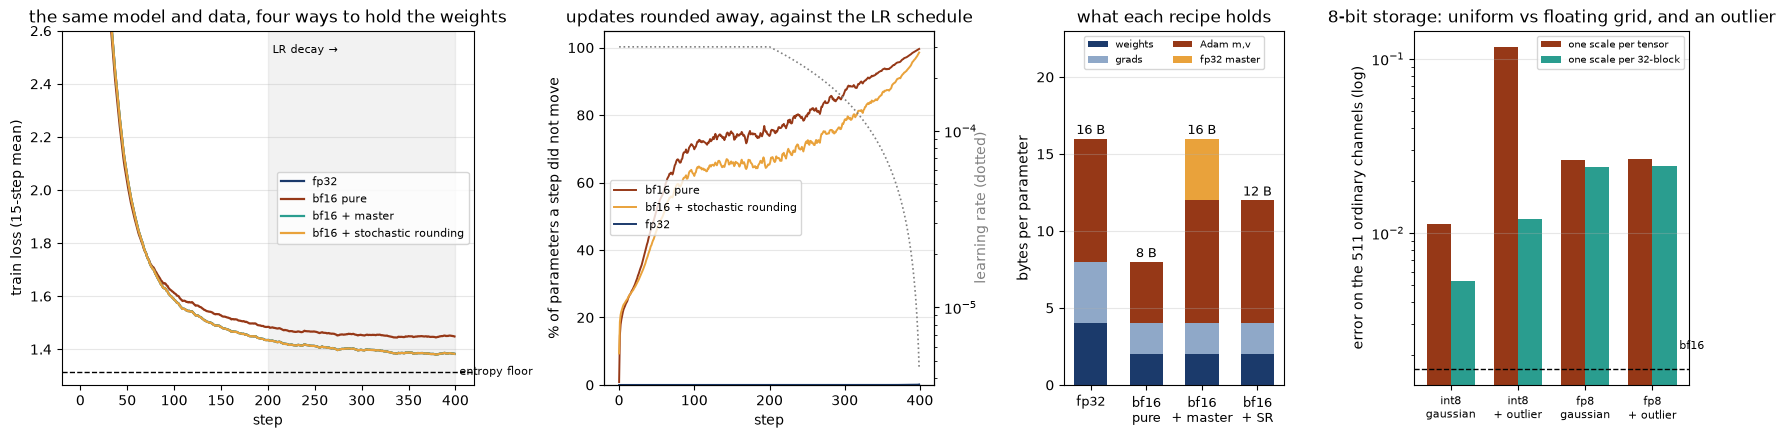

→ out\02_precision.png


In [22]:
fig, ax = plt.subplots(1, 4, figsize=(21, 4.6), gridspec_kw={"width_ratios": [1.5, 1.2, 0.8, 1.0], "wspace": 0.42})
colors = {"fp32": "#1b3a6b", "bf16 pure": "#963817", "bf16 + master": "#2a9d8f", "bf16 + stochastic rounding": "#e9a23b"}
for mode, losses in runs.items():
    k = 15
    smooth = [sum(losses[max(0, i - k):i + 1]) / len(losses[max(0, i - k):i + 1]) for i in range(len(losses))]
    ax[0].plot(smooth, label=mode, color=colors[mode], lw=1.6)
ax[0].set_ylim(task.floor - 0.05, 2.6)
ax[0].axhline(task.floor, ls="--", c="k", lw=1); ax[0].text(STEPS, task.floor, " entropy floor", va="center", fontsize=8)
ax[0].axvspan(STABLE_STEPS, STEPS, color="k", alpha=.05); ax[0].text(STABLE_STEPS + 5, 2.55, "LR decay →", va="top", fontsize=8)
ax[0].set_xlabel("step"); ax[0].set_ylabel("train loss (15-step mean)"); ax[0].set_title("the same model and data, four ways to hold the weights")
ax[0].legend(fontsize=8)

for mode in ("bf16 pure", "bf16 + stochastic rounding", "fp32"):
    ax[1].plot([100 * u for u in unmoved[mode]], color=colors[mode], lw=1.4, label=mode)
ax[1].set_ylabel("% of parameters a step did not move"); ax[1].set_xlabel("step")
ax1b = ax[1].twinx(); ax1b.plot([lr_at(s) for s in range(STEPS)], color="gray", ls=":", lw=1.2); ax1b.set_yscale("log")
ax1b.set_ylabel("learning rate (dotted)", color="gray", labelpad=-2)
ax[1].set_title("updates rounded away, against the LR schedule"); ax[1].legend(fontsize=8, loc="center left"); ax[1].set_ylim(0, 105)

parts = {"fp32": [("weights", 4), ("grads", 4), ("Adam m,v", 8)],
         "bf16 pure": [("weights", 2), ("grads", 2), ("Adam m,v", 4)],
         "bf16 + master": [("weights", 2), ("grads", 2), ("Adam m,v", 8), ("fp32 master", 4)],
         "bf16 + stochastic rounding": [("weights", 2), ("grads", 2), ("Adam m,v", 8)]}
pc = {"weights": "#1b3a6b", "grads": "#8fa8c8", "Adam m,v": "#963817", "fp32 master": "#e9a23b"}
for i, mode in enumerate(MODES):
    bottom = 0
    for name, b in parts[mode]:
        ax[2].bar(i, b, bottom=bottom, color=pc[name], label=name if i == 0 or name == "fp32 master" and i == 2 else None, width=0.6)
        bottom += b
    ax[2].text(i, bottom + 0.3, f"{bottom} B", ha="center", fontsize=9)
ax[2].set_xticks(range(len(MODES))); ax[2].set_xticklabels(["fp32", "bf16\npure", "bf16\n+ master", "bf16\n+ SR"], fontsize=9)
ax[2].set_ylabel("bytes per parameter"); ax[2].set_title("what each recipe holds"); ax[2].set_ylim(0, 23)
ax[2].legend(fontsize=7, loc="upper center", ncol=2)

xs = range(len(q_rows)); w = 0.36
ax[3].bar([i - w / 2 for i in xs], [r[1] for r in q_rows], w, label="one scale per tensor", color="#963817")
ax[3].bar([i + w / 2 for i in xs], [r[2] for r in q_rows], w, label="one scale per 32-block", color="#2a9d8f")
ax[3].axhline(bf16_err, ls="--", c="k", lw=1); ax[3].text(len(q_rows) - 0.6, bf16_err * 1.3, "bf16", fontsize=8)
ax[3].set_yscale("log"); ax[3].set_xticks(list(xs)); ax[3].set_xticklabels([r[0] for r in q_rows], fontsize=8)
ax[3].set_ylabel("error on the 511 ordinary channels (log)"); ax[3].set_title("8-bit storage: uniform vs floating grid, and an outlier"); ax[3].legend(fontsize=7)
for a in ax:
    a.grid(axis="y", alpha=.3)
fig.savefig(OUT / "02_precision.png", dpi=140, bbox_inches="tight")
plt.show()
print(f"→ {OUT / '02_precision.png'}")

---

# 03 — collectives: how tensors get taken apart and put back together

Every kind of parallelism (data, tensor, pipeline, expert, context) cuts some tensor along some
axis and then uses *collectives*, operations that all ranks run together, to move the pieces.
Five collectives cover almost everything:

| collective | before | after |
|---|---|---|
| `broadcast` | one rank has `x` | every rank has `x` |
| `reduce_scatter` | every rank has its own `x_r` | rank `r` has chunk `r` of `Σ x_r` |
| `all_gather` | rank `r` has chunk `r` | every rank has all chunks, concatenated |
| `all_reduce` | every rank has `x_r` | every rank has `Σ x_r` — and it **is** `reduce_scatter` then `all_gather` |
| `all_to_all` | rank `r` has chunks `(r→0), …, (r→n−1)` | rank `j` has chunks `(0→j), …, (n−1→j)` — a transpose of the chunk grid |

No GPUs and no `torch.distributed` here: the ranks are entries of a Python list, and the
"network" is a counter of the bytes each rank sends. This is enough to derive the communication
cost of each primitive exactly; section 04 uses these costs. A real `torch.distributed` version
of the measurements is in `dist/collectives_bench.py`, for a machine with several GPUs (or a
Linux machine with several cores).

Runtime: a second. Dependencies: `torch`, `matplotlib`.

In [23]:
from __future__ import annotations

import json
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import torch

if hasattr(sys.stdout, "reconfigure"):
    sys.stdout.reconfigure(encoding="utf-8", errors="replace")
torch.manual_seed(0)

OUT = Path("out")
OUT.mkdir(exist_ok=True)

## 1. A world of virtual ranks

`World.send(src, dst, tensor)` is the only way data moves. It returns a copy (so no rank can
peek at another's memory by accident) and charges `src` for the bytes. Every collective below
is written only in terms of `send`.

In [24]:
class World:
    def __init__(self, n):
        self.n = n
        self.sent = [0] * n          # bytes each rank has sent
        self.steps = 0               # synchronous communication rounds

    def send(self, src, dst, t):
        assert src != dst
        self.sent[src] += t.numel() * t.element_size()
        return t.clone()

    def round(self):
        self.steps += 1

    def reset(self):
        self.sent, self.steps = [0] * self.n, 0

    def report(self, name, M):
        per_rank = max(self.sent)
        return {"collective": name, "bytes/rank": per_rank, "as a fraction of M": round(per_rank / M, 3),
                "rounds": self.steps}


def chunks(t, n):
    return list(t.chunk(n))


def broadcast(w: World, xs, src):
    # naive: the root sends the whole tensor to everybody. (n−1)·M from one rank.
    out = [None] * w.n
    for r in range(w.n):
        out[r] = xs[src] if r == src else w.send(src, r, xs[src])
    w.round()
    return out

## 2. The ring: reduce-scatter and all-gather

`n` ranks in a ring, each tensor cut into `n` chunks. **Reduce-scatter** takes `n−1` rounds:
in every round each rank passes one partial sum to its right-hand neighbour and adds the one
that arrives from the left. After `n−1` rounds every chunk has visited every rank exactly
once, so each rank ends up with one fully-summed chunk. **All-gather** is the same ring run
forwards without the adding: each rank passes along the chunk it just received.

Both cost each rank `(n−1)/n · M` bytes — the whole tensor, minus its own share — spread over
`n−1` rounds. In round `s`, rank `r` sends chunk `(r − s) mod n`. With this schedule every link
is busy in every round and no rank waits for another.

In [25]:
def reduce_scatter(w: World, xs):
    """xs[r]: the full tensor on rank r. Returns chunk r of Σ xs, held by rank r."""
    n = w.n
    buf = [chunks(x, n) for x in xs]                  # buf[r][c]: rank r's running partial sum of chunk c
    for s in range(n - 1):
        incoming = []
        for r in range(n):
            c = (r - s) % n
            dst = (r + 1) % n
            incoming.append((dst, c, w.send(r, dst, buf[r][c])))
        for dst, c, t in incoming:                    # deliveries land after the round, all at once
            buf[dst][c] = buf[dst][c] + t
        w.round()
    # after n−1 rounds, rank r holds the complete sum of chunk (r + 1) mod n; relabel so rank r owns chunk r
    return [buf[(c - 1) % n][c] for c in range(n)]


def all_gather(w: World, cs):
    """cs[r]: chunk r on rank r. Returns the full concatenation on every rank."""
    n = w.n
    have = [{r: cs[r]} for r in range(n)]             # have[r]: chunks rank r holds so far
    for s in range(n - 1):
        incoming = []
        for r in range(n):
            c = (r - s) % n                           # the chunk that arrived last round (own chunk in round 0)
            dst = (r + 1) % n
            incoming.append((dst, c, w.send(r, dst, have[r][c])))
        for dst, c, t in incoming:
            have[dst][c] = t
        w.round()
    return [torch.cat([have[r][c] for c in range(n)]) for r in range(n)]


def all_reduce(w: World, xs):
    return all_gather(w, reduce_scatter(w, xs))


def all_to_all(w: World, xs):
    """xs[r] is cut into n chunks; chunk j of rank r goes to rank j. Every pair talks once."""
    n = w.n
    parts = [chunks(x, n) for x in xs]
    out = [[None] * n for _ in range(n)]
    for r in range(n):
        for j in range(n):
            out[j][r] = parts[r][j] if r == j else w.send(r, j, parts[r][j])
    w.round()
    return [torch.cat(o) for o in out]

## 3. Check them, then bill them

First correctness against the single-tensor answer, then the byte counts. `M` is the size of one
rank's tensor; for example, the gradient of a 7B model in bf16 is 14 GB.

In [26]:
n, M_elems = 8, 8 * 1024          # 8 ranks, 32 KiB fp32 per rank: the bytes scale linearly, the fractions do not change
xs = [torch.randn(M_elems) for _ in range(n)]
truth = torch.stack(xs).sum(0)
M = M_elems * 4

rows = []
w = World(n)
out = broadcast(w, xs, src=0); assert all(torch.equal(o, xs[0]) for o in out)
rows.append(w.report("broadcast (root's bytes)", M)); w.reset()

close = lambda a, b: torch.allclose(a, b, atol=1e-5)   # the ring sums in a different order: last-bit differences are expected
rs = reduce_scatter(w, xs); assert close(torch.cat(rs), truth)
rows.append(w.report("reduce_scatter", M)); w.reset()

ag = all_gather(w, rs); assert all(close(a, truth) for a in ag)
rows.append(w.report("all_gather", M)); w.reset()

ar = all_reduce(w, xs); assert all(close(a, truth) for a in ar)
rows.append(w.report("all_reduce = RS + AG", M)); w.reset()

a2a = all_to_all(w, xs)
assert all(torch.equal(a2a[j], torch.cat([chunks(xs[r], n)[j] for r in range(n)])) for j in range(n))
rows.append(w.report("all_to_all", M)); w.reset()

print(f"{'collective':<26}{'bytes/rank':>12}{'÷ M':>8}{'rounds':>8}   formula")
formulas = {"broadcast (root's bytes)": "(n−1)·M", "reduce_scatter": "(n−1)/n · M", "all_gather": "(n−1)/n · M",
            "all_reduce = RS + AG": "2(n−1)/n · M", "all_to_all": "(n−1)/n · M, but every pair at once"}
for r in rows:
    print(f"{r['collective']:<26}{r['bytes/rank']:>12,}{r['as a fraction of M']:>8}{r['rounds']:>8}   {formulas[r['collective']]}")
print(f"\nn = {n}: 2(n−1)/n = {2 * (n - 1) / n:.3f} — all_reduce moves almost exactly 2M per rank, whatever n is")

collective                  bytes/rank     ÷ M  rounds   formula
broadcast (root's bytes)       229,376     7.0       1   (n−1)·M
reduce_scatter                  28,672   0.875       7   (n−1)/n · M
all_gather                      28,672   0.875       7   (n−1)/n · M
all_reduce = RS + AG            57,344    1.75      14   2(n−1)/n · M
all_to_all                      28,672   0.875       1   (n−1)/n · M, but every pair at once

n = 8: 2(n−1)/n = 1.750 — all_reduce moves almost exactly 2M per rank, whatever n is


**All-reduce costs about 2M per rank, independent of `n`.** This is why data parallelism scales:
adding GPUs does not add bytes per GPU. It adds *rounds*, `2(n−1)` of them, and each round costs
latency. Large tensors are bandwidth-bound and suit rings; small ones are latency-bound and suit
trees (`log n` rounds, more bytes). NCCL chooses the algorithm by message size.

**All-to-all moves the same bytes as all-gather, but between all pairs at once.** On a ring only
neighbours communicate; in all-to-all every link carries traffic simultaneously, so it is the
first collective to suffer from an oversubscribed switch or a bad network mapping. This is the
main communication problem of expert parallelism.

**`all_reduce = reduce_scatter + all_gather`.** ZeRO and FSDP stop after the first half: after
reduce-scatter each rank holds one shard of the summed gradient, which is enough to update its
own shard of the parameters. The all-gather then moves parameters instead of gradients. The bytes
are the same as in DDP's all-reduce, and the optimizer state is divided by `n`. Section 04
implements this.

## 4. From bytes to time

Wall-clock time is the bytes divided by the bandwidth of the slowest link the collective
crosses, plus rounds × latency. For a 7B model's bf16 gradients (14 GB) on 8 ranks:

In [27]:
LINKS = {"NVLink, inside an H100 node": 450e9, "InfiniBand 400 Gb/s, between nodes": 50e9, "PCIe 4.0 x16": 25e9}
grad_bytes = 7e9 * 2
print(f"all_reduce of {grad_bytes / 1e9:.0f} GB across 8 ranks = {2 * 7 / 8 * grad_bytes / 1e9:.1f} GB per rank")
for name, bw in LINKS.items():
    print(f"  over {name:<38} {2 * 7 / 8 * grad_bytes / bw * 1e3:7.0f} ms")
print("a forward+backward of 7B on 8×H100 at a modest 4k tokens per GPU is ~1 s: the NVLink case hides behind it, "
      "the InfiniBand case does not — hence gradient bucketing, overlap with backward, and large per-GPU batches.")

all_reduce of 14 GB across 8 ranks = 24.5 GB per rank
  over NVLink, inside an H100 node                 54 ms
  over InfiniBand 400 Gb/s, between nodes         490 ms
  over PCIe 4.0 x16                               980 ms
a forward+backward of 7B on 8×H100 at a modest 4k tokens per GPU is ~1 s: the NVLink case hides behind it, the InfiniBand case does not — hence gradient bucketing, overlap with backward, and large per-GPU batches.


⚠ These are unidirectional, idealized bandwidths, and latency is ignored, so the numbers are
orders of magnitude. The ratio between the rows gives the placement rule: collectives that move
a lot of data go on the fast link, and between nodes as little as possible is sent and the
communication is overlapped with compute.

## 5. Where each collective lives in one training step

| axis | what is cut | collective | how often |
|---|---|---|---|
| DP (DDP) | the batch | `all_reduce` of gradients | once per step, overlapped with backward |
| DP + ZeRO-1/2 | batch, optimizer state, gradients | `reduce_scatter` grads, `all_gather` params | once per step |
| ZeRO-3 / FSDP | everything, per layer | `all_gather` params before each layer, `reduce_scatter` grads after | every layer, forward and backward |
| TP | inside the layer | `all_reduce` of activations | twice per block (attn, MLP), forward and backward |
| TP + SP | plus norms/dropout along the sequence | `reduce_scatter` + `all_gather` instead of `all_reduce` | same count, same bytes, activations sharded |
| EP | experts across ranks | `all_to_all` dispatch, `all_to_all` combine | twice per MoE layer |
| PP | layers across stages | point-to-point `send`/`recv` of activations | per micro-batch, per stage boundary |

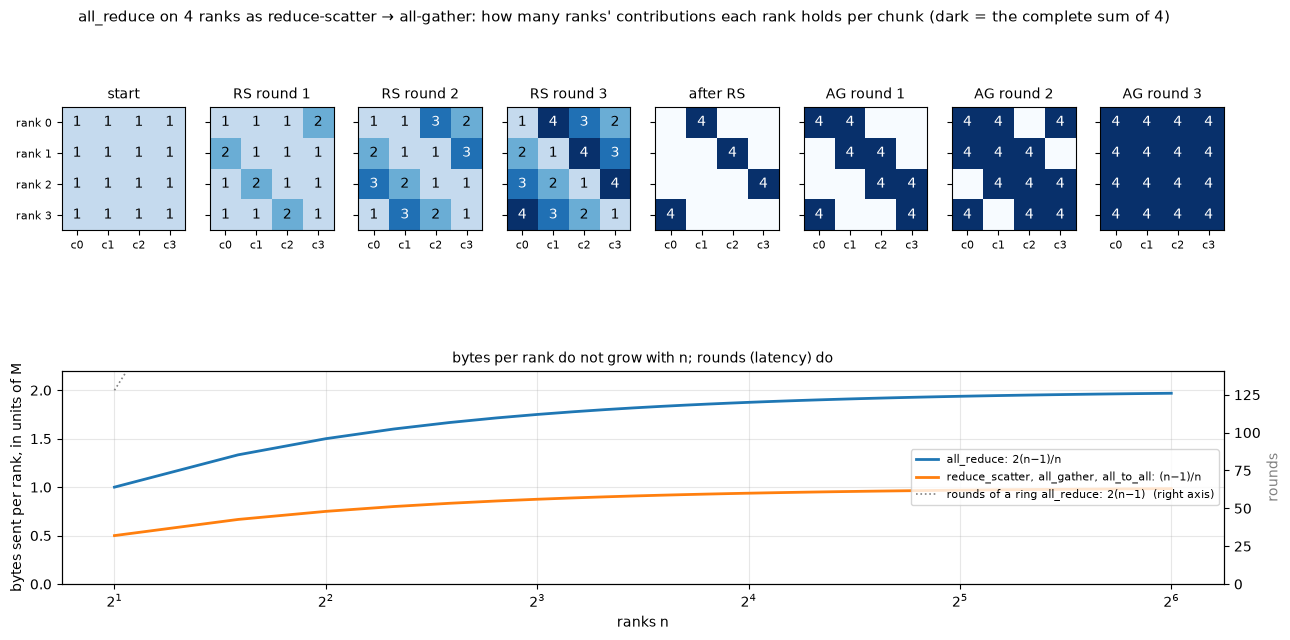

→ out\03_collectives.png


In [28]:
# ---- figure: the ring, round by round (n=4), and the byte formulas against n
def ring_history(n):
    """For a reduce-scatter followed by an all-gather on n ranks: after each round, how many
    ranks' contributions does rank r hold for chunk c? (0 = nothing, n = the complete sum)."""
    contrib = [[1] * n for _ in range(n)]      # RS start: every rank holds its own contribution to every chunk
    hist = [("start", [row[:] for row in contrib])]
    for s in range(n - 1):
        new = [row[:] for row in contrib]
        for r in range(n):
            c, dst = (r - s) % n, (r + 1) % n
            new[dst][c] = contrib[dst][c] + contrib[r][c]
        contrib = new
        hist.append((f"RS round {s + 1}", [row[:] for row in contrib]))
    # after RS: rank r keeps only its complete chunk (r+1)%n; everything else is discarded
    have = [[contrib[r][c] if c == (r + 1) % n else 0 for c in range(n)] for r in range(n)]
    hist.append(("after RS", [row[:] for row in have]))
    for s in range(n - 1):
        new = [row[:] for row in have]
        for r in range(n):
            c, dst = (r + 1 - s) % n, (r + 1) % n
            new[dst][c] = have[r][c]
        have = new
        hist.append((f"AG round {s + 1}", [row[:] for row in have]))
    return hist


N_FIG = 4
hist = ring_history(N_FIG)
fig = plt.figure(figsize=(15, 6.6))
gs = fig.add_gridspec(2, len(hist), height_ratios=[1, 1.15], hspace=0.55)
for i, (title, grid) in enumerate(hist):
    a = fig.add_subplot(gs[0, i])
    a.imshow(grid, cmap="Blues", vmin=0, vmax=N_FIG)
    for r in range(N_FIG):
        for c in range(N_FIG):
            if grid[r][c]:
                a.text(c, r, str(grid[r][c]), ha="center", va="center", fontsize=10,
                       color="white" if grid[r][c] >= N_FIG - 1 else "black")
    a.set_title(title, fontsize=10); a.set_xticks(range(N_FIG)); a.set_yticks(range(N_FIG))
    a.set_xticklabels([f"c{c}" for c in range(N_FIG)], fontsize=8)
    a.set_yticklabels([f"rank {r}" for r in range(N_FIG)] if i == 0 else [], fontsize=8)
fig.suptitle(f"all_reduce on {N_FIG} ranks as reduce-scatter → all-gather: how many ranks' contributions each rank holds "
             f"per chunk (dark = the complete sum of {N_FIG})", fontsize=11, y=0.98)

a = fig.add_subplot(gs[1, :])
ns = list(range(2, 65))
a.plot(ns, [2 * (k - 1) / k for k in ns], lw=2, label="all_reduce: 2(n−1)/n")
a.plot(ns, [(k - 1) / k for k in ns], lw=2, label="reduce_scatter, all_gather, all_to_all: (n−1)/n")
a.plot(ns, [2 * (k - 1) for k in ns], lw=1.2, ls=":", color="gray", label="rounds of a ring all_reduce: 2(n−1)  (right axis)")
a.set_xscale("log", base=2); a.set_xlabel("ranks n"); a.set_ylabel("bytes sent per rank, in units of M")
a.set_ylim(0, 2.2); a.set_title("bytes per rank do not grow with n; rounds (latency) do", fontsize=10)
a2 = a.twinx(); a2.set_ylim(0, 2.2 * 64); a2.set_ylabel("rounds", color="gray")
a.legend(fontsize=8, loc="center right"); a.grid(alpha=.3)
fig.savefig(OUT / "03_collectives.png", dpi=140, bbox_inches="tight")
plt.show()
print(f"→ {OUT / '03_collectives.png'}")

## 6. The same measurements on real ranks

`dist/collectives_bench.py` runs the five primitives through `torch.distributed` — NCCL on
GPUs, gloo on CPU cores — for message sizes from 1 MB to 256 MB and writes the achieved
bandwidth to `out/dist_collectives.json`. On a multi-GPU box:

```bash
torchrun --nproc_per_node=4 dist/collectives_bench.py
```

If the file exists, the cell below prints it. Expected pattern: the bus bandwidth of `all_reduce`
approaches the link's rating at large sizes and drops at small ones (the latency term), and
`all_to_all` is slower than `all_gather` on anything other than a full NVSwitch.

In [29]:
bench = OUT / "dist_collectives.json"
if bench.exists():
    data = json.loads(bench.read_text())
    print(f"backend {data['backend']}, world size {data['world_size']}, device {data['device']}")
    print(f"{'collective':<16}" + "".join(f"{s:>12}" for s in data["sizes_mb"]) + "   (achieved bus GB/s per message size, MB)")
    for name, vals in data["bus_gbps"].items():
        print(f"{name:<16}" + "".join(f"{v:>12.1f}" for v in vals))
else:
    print("no out/dist_collectives.json — run dist/collectives_bench.py on a machine with several GPUs (or Linux cores)")

backend nccl, world size 2, device cuda:0
collective                 1           4          16          64         256   (achieved bus GB/s per message size, MB)
broadcast                3.6         0.6         1.2         2.6         2.8
reduce_scatter           0.0         0.2         0.7         1.2         1.6
all_gather               0.0         0.2         0.6         1.3         1.7
all_reduce               0.1         0.4         1.4         1.7         1.9
all_to_all               0.0         0.2         0.7         1.4         1.6


The recorded run uses a slow setup: two A100s in different PCIe slots of a shared server,
connected through the host bridge, without NVLink or NVSwitch. At 256 MB the all-reduce reaches
about 2 GB/s of bus bandwidth, an order of magnitude below the ~25 GB/s of PCIe 4.0 and more than
two hundred times below the 450 GB/s of NVLink used in section 4. At 1 MB every collective is
near zero: the message is too small to amortize the fixed cost of starting it, which is the
latency term that the byte counter does not model.

With this bandwidth, the 24.5 GB per rank of a 7B all-reduce from section 4 would take over ten
seconds. The link a collective runs on changes its cost by two orders of magnitude, so it is
worth checking the topology of a new machine with `nvidia-smi topo -m`.

---

# 04 — data and tensor parallelism, on ranks that are lists

Each kind of parallelism can be described by: the problem it solves → what is cut → which
collective → which link. Here we implement the two used in almost every large run, **data
parallelism with ZeRO** and **tensor parallelism**, on virtual ranks, check them against the
single-device computation, and count their communication with the formulas from section 03.
Pipeline and expert parallelism get a paragraph and a formula each.

The model is the same small GPT as in sections 01–02. Every "rank" is an entry in a Python list;
the collectives are implemented semantically (sum, chunk, concatenate) with a counter of the
bytes each would move on real hardware.

At the end, a calculator: a 7B model on eight 80 GB GPUs under six layouts, with memory per GPU
and bytes per step.

Runtime ~10 s on CPU. Dependencies: `torch`, `matplotlib`.

In [30]:
from __future__ import annotations

import copy
import os
import sys
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

if hasattr(sys.stdout, "reconfigure"):
    sys.stdout.reconfigure(encoding="utf-8", errors="replace")
torch.manual_seed(0)

OUT = Path("out")
OUT.mkdir(exist_ok=True)

In [31]:
@dataclass
class Cfg:
    vocab: int = 512
    block: int = 64
    n_layer: int = 4
    n_head: int = 4
    n_kv_head: int = 2       # GQA 2:1 — it limits tensor parallelism, see section 3
    n_embd: int = 128
    d_ff: int = 384


def norm(x):
    return F.rms_norm(x, (x.size(-1),))


class Attention(nn.Module):
    def __init__(self, c: Cfg):
        super().__init__()
        self.nh, self.nkv, self.dh = c.n_head, c.n_kv_head, c.n_embd // c.n_head
        self.q = nn.Linear(c.n_embd, c.n_head * self.dh, bias=False)
        self.k = nn.Linear(c.n_embd, c.n_kv_head * self.dh, bias=False)
        self.v = nn.Linear(c.n_embd, c.n_kv_head * self.dh, bias=False)
        self.o = nn.Linear(c.n_head * self.dh, c.n_embd, bias=False)

    def forward(self, x):
        B, T, C = x.shape
        q = self.q(x).view(B, T, self.nh, self.dh).transpose(1, 2)
        k = self.k(x).view(B, T, self.nkv, self.dh).transpose(1, 2).repeat_interleave(self.nh // self.nkv, 1)
        v = self.v(x).view(B, T, self.nkv, self.dh).transpose(1, 2).repeat_interleave(self.nh // self.nkv, 1)
        y = F.scaled_dot_product_attention(q, k, v, is_causal=True)
        return self.o(y.transpose(1, 2).reshape(B, T, C))


class MLP(nn.Module):
    def __init__(self, c: Cfg):
        super().__init__()
        self.gate = nn.Linear(c.n_embd, c.d_ff, bias=False)
        self.up = nn.Linear(c.n_embd, c.d_ff, bias=False)
        self.down = nn.Linear(c.d_ff, c.n_embd, bias=False)

    def forward(self, x):
        return self.down(F.silu(self.gate(x)) * self.up(x))


class Block(nn.Module):
    def __init__(self, c: Cfg):
        super().__init__()
        self.attn, self.mlp = Attention(c), MLP(c)

    def forward(self, x):
        x = x + self.attn(norm(x))
        return x + self.mlp(norm(x))


class GPT(nn.Module):
    def __init__(self, c: Cfg):
        super().__init__()
        self.c = c
        self.wte = nn.Embedding(c.vocab, c.n_embd)
        self.blocks = nn.ModuleList(Block(c) for _ in range(c.n_layer))
        self.head = nn.Linear(c.n_embd, c.vocab, bias=False)

    def forward(self, idx, targets=None):
        x = norm(self.wte(idx))
        for b in self.blocks:
            x = b(x)
        logits = self.head(norm(x))
        if targets is None:
            return logits, None
        return logits, F.cross_entropy(logits.view(-1, self.c.vocab), targets.reshape(-1))


class Comm:
    """Bills each collective with the per-rank byte count from section 03 and keeps a ledger."""
    def __init__(self, n):
        self.n, self.ledger = n, []

    def _bill(self, name, per_rank_bytes):
        self.ledger.append((name, per_rank_bytes))

    def all_reduce(self, xs, name="all_reduce"):
        s = torch.stack(xs).sum(0)
        self._bill(name, 2 * (self.n - 1) / self.n * s.numel() * s.element_size())
        return [s.clone() for _ in xs]

    def reduce_scatter(self, xs, name="reduce_scatter"):
        s = torch.stack(xs).sum(0)
        self._bill(name, (self.n - 1) / self.n * s.numel() * s.element_size())
        return list(s.chunk(self.n))

    def all_gather(self, shards, name="all_gather"):
        full = torch.cat(shards)
        self._bill(name, (self.n - 1) / self.n * full.numel() * full.element_size())
        return [full.clone() for _ in shards]

    def total(self):
        return sum(b for _, b in self.ledger)

    def summary(self):
        by = {}
        for k, b in self.ledger:
            by[k] = by.get(k, 0) + b
        return by


cfg = Cfg()
N_RANKS = 4
B, T = 8, cfg.block
torch.manual_seed(0)
reference = GPT(cfg)
x = torch.randint(0, cfg.vocab, (B, T))
y = torch.randint(0, cfg.vocab, (B, T))
P = sum(p.numel() for p in reference.parameters())
print(f"model: {P / 1e6:.2f}M parameters, {N_RANKS} virtual ranks, batch {B}×{T}")

model: 0.92M parameters, 4 virtual ranks, batch 8×64


## 1. Data parallelism: the batch is cut, the gradients are summed

Every rank holds a full replica. The batch of 8 sequences becomes 4 micro-batches of 2; each
rank runs forward and backward on its own, and then one `all_reduce` averages the gradients.
The result equals the full-batch gradient: the mean of per-example gradients is linear, so it
does not matter on which rank each example was processed.

In [32]:
def flat_grad(m):
    return torch.cat([p.grad.reshape(-1) for p in m.parameters()])


# the single-device answer
_, loss = reference(x, y)
loss.backward()
g_full = flat_grad(reference).clone()
reference.zero_grad(set_to_none=True)

# the data-parallel version
comm = Comm(N_RANKS)
replicas = [copy.deepcopy(reference) for _ in range(N_RANKS)]
xb, yb = x.chunk(N_RANKS), y.chunk(N_RANKS)
for r, m in enumerate(replicas):
    _, l = m(xb[r], yb[r])
    l.backward()
g_dp = comm.all_reduce([flat_grad(m) for m in replicas], "all_reduce(grads)")
g_dp = [g / N_RANKS for g in g_dp]                      # mean, not sum: each rank saw 1/N of the batch

print(f"DP gradient == full-batch gradient: {torch.allclose(g_dp[0], g_full, atol=1e-6)}   "
      f"(max |Δ| = {(g_dp[0] - g_full).abs().max():.1e})")
dp_bytes = comm.total()
print(f"communication per step: {dp_bytes / 1e6:.2f} MB per rank = 2·(n−1)/n × {P * 4 / 1e6:.2f} MB of fp32 gradients")
print(f"that number does not depend on the batch: double the micro-batch and the FLOPs double, the bytes do not")

DP gradient == full-batch gradient: True   (max |Δ| = 8.4e-09)
communication per step: 5.51 MB per rank = 2·(n−1)/n × 3.67 MB of fp32 gradients
that number does not depend on the batch: double the micro-batch and the FLOPs double, the bytes do not


One `all_reduce` of the *whole gradient* per step, regardless of batch size. This is why DP
scales: communication is fixed by the model, computation grows with the per-rank batch, and DDP
overlaps the reduction with the backward pass bucket by bucket, so on a fast link it is hidden
completely. Gradient accumulation works the same way: `k` micro-steps, one reduction. The two
limits: memory is not saved at all (each replica holds all 16 bytes per parameter), and the
total batch cannot grow indefinitely, because beyond the critical batch size more tokens per
step no longer give proportionally faster training.

## 2. ZeRO-1: all-reduce split in two

Section 03 showed that `all_reduce = reduce_scatter + all_gather`. After the `reduce_scatter`,
rank `r` holds shard `r` of the summed gradient. If rank `r` is the only owner of shard `r` of
the parameters and of the Adam state, this is all it needs to run the optimizer on its shard.
Then an `all_gather` of the *updated parameters* gives every replica the new model. The bytes
are the same as in DDP, and the optimizer state is divided by `n`.

In [33]:
def adamw_update(p, g, m, v, t, lr=1e-3, b1=0.9, b2=0.95, wd=0.1, eps=1e-8):
    """One AdamW step on flat tensors. Element-wise: shard r of the output needs shard r of the inputs."""
    m.mul_(b1).add_(g, alpha=1 - b1)
    v.mul_(b2).addcmul_(g, g, value=1 - b2)
    upd = (m / (1 - b1 ** t)) / ((v / (1 - b2 ** t)).sqrt() + eps)
    return p * (1 - lr * wd) - lr * upd


# the DDP reference: every rank runs AdamW on the whole all-reduced gradient (g_dp from section 1)
p0 = torch.cat([p.detach().reshape(-1) for p in reference.parameters()])
m_ref, v_ref = torch.zeros_like(p0), torch.zeros_like(p0)
p_ref = adamw_update(p0.clone(), g_dp[0], m_ref, v_ref, t=1)

# ZeRO-1 on the virtual ranks: every rank keeps Adam state ONLY for its own shard
comm = Comm(N_RANKS)
grads = [flat_grad(m) / N_RANKS for m in replicas]                                # each rank: its local gradient
shard_m = [torch.zeros(P // N_RANKS) for _ in range(N_RANKS)]
shard_v = [torch.zeros(P // N_RANKS) for _ in range(N_RANKS)]
g_shards = comm.reduce_scatter(grads, "reduce_scatter(grads)")
p_shards = [adamw_update(p0.chunk(N_RANKS)[r].clone(), g_shards[r], shard_m[r], shard_v[r], t=1) for r in range(N_RANKS)]
p_new = comm.all_gather(p_shards, "all_gather(params)")

print(f"ZeRO-1 parameters == DDP parameters, bit for bit: {torch.equal(p_new[0], p_ref)}")
print(f"communication per step: {comm.total() / 1e6:.2f} MB per rank — the same as DDP's {dp_bytes / 1e6:.2f} MB; "
      f"ledger: {', '.join(f'{k} {b / 1e6:.2f} MB' for k, b in comm.summary().items())}")
print(f"Adam state per rank: {2 * 4 * P / N_RANKS / 1e6:.2f} MB instead of {2 * 4 * P / 1e6:.2f} MB  (÷{N_RANKS})")

ZeRO-1 parameters == DDP parameters, bit for bit: True
communication per step: 5.51 MB per rank — the same as DDP's 5.51 MB; ledger: reduce_scatter(grads) 2.75 MB, all_gather(params) 2.75 MB
Adam state per rank: 1.84 MB instead of 7.34 MB  (÷4)


The parameters are identical bit for bit, the communication is the same, and the optimizer
memory per rank is a quarter. **ZeRO-1 shards the optimizer state at no extra communication
cost**, because AdamW is *element-wise*: the update of parameter `i` depends only on gradient
`i`, `m_i` and `v_i`, so any partition of the parameters is a valid partition of the work. An
optimizer that is not element-wise (for example, Muon, which needs whole matrices) does not have
this property.

ZeRO-2 also shards the gradients (the reduce-scatter already produced shards, so the full
gradient is simply not kept). ZeRO-3 / FSDP shards the parameters as well and pays with an
`all_gather` of each layer's weights right before that layer runs, in forward and in backward:
the extra `(n−1)/n · 2N` bytes per step in the calculator below.

## 3. Tensor parallelism: cutting inside the layer

TP is used when the model does not fit on one rank or a single layer is too slow. It cuts
*inside* a layer. For the SwiGLU MLP the cut that needs one collective instead of three is:
`gate` and `up` **by columns** (each rank owns a slice of the hidden dimension), `down` **by
rows** (each rank multiplies its slice back to `d`), and the partial outputs are summed with one
`all_reduce`. The element-wise `silu(gate)·up` stays local because both operands are cut the
same way. This is the `f / f̄` pair of Megatron-LM.

In [34]:
def mlp_tp(mlp: MLP, x, comm: Comm):
    """The MLP run column/row-parallel over comm.n ranks. Returns the output on each rank."""
    n = comm.n
    Wg, Wu, Wd = mlp.gate.weight, mlp.up.weight, mlp.down.weight     # (d_ff, d), (d_ff, d), (d, d_ff)
    partial = []
    for r in range(n):
        g_r, u_r = Wg.chunk(n, dim=0)[r], Wu.chunk(n, dim=0)[r]        # rows of the weight = columns of the output
        d_r = Wd.chunk(n, dim=1)[r]                                     # columns of the weight = rows of the input
        h_r = F.silu(x @ g_r.T) * (x @ u_r.T)                           # local: both operands cut the same way
        partial.append(h_r @ d_r.T)                                     # partial output, still to be summed
    return comm.all_reduce(partial, "all_reduce(MLP output)")


mlp = reference.blocks[0].mlp
h = torch.randn(B, T, cfg.n_embd)
comm = Comm(N_RANKS)
y_tp = mlp_tp(mlp, h, comm)
print(f"TP MLP == single-device MLP: {torch.allclose(y_tp[0], mlp(h), atol=1e-5)}")
print(f"one MLP forward: {comm.total() / 1e3:.1f} KB per rank = 2(n−1)/n × the activation {B}×{T}×{cfg.n_embd} in fp32; "
      f"backward moves the same again")

TP MLP == single-device MLP: True
one MLP forward: 393.2 KB per rank = 2(n−1)/n × the activation 8×64×128 in fp32; backward moves the same again


**Attention** is cut by heads: with 4 query heads on 4 ranks each rank owns one head's `q`
slice, computes its own attention, and the `o` projection is row-parallel with an
`all_reduce`, the same structure as the MLP. That makes two `all_reduce`s of the activation per
block in forward and two more in backward: a collective in every layer on a tensor of size
`b·s·d`. This is why TP is used only over NVLink.

**GQA limits the TP degree.** The KV heads also have to be split across ranks, and this model
has only 2 of them. TP = 4 either duplicates each KV head on two ranks (the usual solution, at
the cost of some memory and extra work in the `k`, `v` projections) or is impossible.
Llama-3-70B has 8 KV heads: TP = 8 fits exactly, TP = 16 requires duplication. The number of KV
heads is an architectural choice that constrains the parallel layout later.

In [35]:
print(f"TP degree vs KV heads for this model (n_head={cfg.n_head}, n_kv_head={cfg.n_kv_head}):")
for tp in (1, 2, 4, 8):
    q_per = cfg.n_head / tp
    kv_per = cfg.n_kv_head / tp
    status = ("ok" if kv_per >= 1 else f"KV heads replicated ×{int(1 / kv_per)}") if q_per >= 1 else "more ranks than query heads: impossible"
    print(f"  TP={tp}: {q_per:g} query heads/rank, {max(kv_per, 1):g} KV head(s)/rank — {status}")

TP degree vs KV heads for this model (n_head=4, n_kv_head=2):
  TP=1: 4 query heads/rank, 2 KV head(s)/rank — ok
  TP=2: 2 query heads/rank, 1 KV head(s)/rank — ok
  TP=4: 1 query heads/rank, 1 KV head(s)/rank — KV heads replicated ×2
  TP=8: 0.5 query heads/rank, 1 KV head(s)/rank — more ranks than query heads: impossible


**Sequence parallelism** is used together with TP. In plain TP the norms and dropout between
the TP regions are replicated on every rank, and so are their activations. SP cuts them along
the sequence and replaces each `all_reduce` by a `reduce_scatter` before the norm and an
`all_gather` after it. The bytes are the same (the identity from section 03), and the activation
memory outside the matmuls is divided by `n`. Megatron uses TP with SP by default.

## 4. Pipeline and expert parallelism

**PP** cuts by layers: stage `k` holds layers `kL/p … (k+1)L/p`, and only activations cross stage
boundaries, point-to-point. This is cheap and works over InfiniBand. The cost is idle time: with
`m` micro-batches in flight, the fraction of time a stage waits is the **bubble** `(p−1)/m`.
More micro-batches reduce the bubble but cost activation memory, since all of them are in
flight. Schedules help further: 1F1B keeps the same bubble with fewer live activations,
interleaved stages reduce it to `(p−1)/(v·m)`, and zero-bubble schedules split backward into its
two matmuls from section 01 (grad-input first, grad-weight when there is a gap) to fill the idle
time.

**EP** places the experts of an MoE layer on different ranks. Tokens are sent to the rank that
owns their expert and back: two `all_to_all` per MoE layer (dispatch and combine) on
`tokens × d` bytes. All-to-all loads every link at once (section 03), routing is imbalanced, and
load balancing has to be global across DP ranks. As a result, MoE layers that are cheap in FLOPs
can still be expensive in wall-clock time.

In [36]:
print(f"{'PP stages p':>12}{'micro-batches m':>17}{'bubble (p−1)/m':>16}{'interleaved v=2':>17}")
for p, m in ((4, 4), (4, 8), (4, 16), (8, 8), (8, 32)):
    print(f"{p:>12}{m:>17}{(p - 1) / m:>16.2f}{(p - 1) / (2 * m):>17.2f}")

 PP stages p  micro-batches m  bubble (p−1)/m  interleaved v=2
           4                4            0.75             0.38
           4                8            0.38             0.19
           4               16            0.19             0.09
           8                8            0.88             0.44
           8               32            0.22             0.11


## 5. The calculator: 7B on eight 80 GB GPUs

The same formulas applied to a real shape, Llama-2-7B: 32 layers, `d = 4096`, `d_ff = 11008`,
32 heads, vocabulary 32 000, 6.7B parameters — trained in BF16 with an FP32 master copy and
AdamW (16 bytes per parameter), sequence length 4096, one sequence per GPU, FlashAttention.

Memory per GPU has four bars: parameters, gradients, optimizer state (master + `m` + `v`),
activations. The activation formula is Megatron's `34·s·b·d` bytes per layer in BF16 (the same
count as section 01), plus the logits. Communication per GPU per step uses section 03's formulas:

| layout | what is sharded | bytes per GPU per step |
|---|---|---|
| DDP | nothing | `all_reduce` grads: `2(n−1)/n · 2N` |
| ZeRO-1 | optimizer state | same as DDP (RS + AG) |
| ZeRO-2 | + gradients | same |
| ZeRO-3 | + parameters | `3 · (n−1)/n · 2N` — two `all_gather`s of params, one `reduce_scatter` |
| TP=8 (+SP) | inside every layer | `4 · L · 2(n−1)/n · (b·s·d·2)` — four activation collectives per layer |
| TP=2 × ZeRO-1 (DP=4) | layers across 2, state across 4 | TP term at n=2 plus the ZeRO term at n=4 on half the params |

In [37]:
GB = 1e9
L, D, DFF, V, S = 32, 4096, 11008, 32000, 4096
N7 = L * (4 * D * D + 3 * D * DFF) + 2 * V * D
N_GPUS, HBM = 8, 80 * GB
BYTES_PARAM = {"params": 2, "grads": 2, "optimizer (master + m + v)": 12}
act_per_layer = 34 * S * 1 * D            # bf16, b = 1, FlashAttention: no s×s term
logits = S * V * 4                        # fp32 logits for the loss
print(f"Llama-2-7B shape: N = {N7 / 1e9:.2f}B parameters; activations {act_per_layer * L / GB:.1f} GB per sequence of {S} + {logits / GB:.1f} GB of logits\n")


def layout(name, shard_params=1, shard_grads=1, shard_opt=1, shard_act=1, comm_bytes=0.0, note=""):
    mem = {"params": BYTES_PARAM["params"] * N7 / shard_params, "grads": BYTES_PARAM["grads"] * N7 / shard_grads,
           "optimizer (master + m + v)": BYTES_PARAM["optimizer (master + m + v)"] * N7 / shard_opt,
           "activations": (act_per_layer * L + logits) / shard_act}
    return {"layout": name, "mem": mem, "total": sum(mem.values()), "comm": comm_bytes, "note": note}


n = N_GPUS
rs_ag = lambda k, nbytes: 2 * (k - 1) / k * nbytes
LAYOUTS = [
    layout("DDP", comm_bytes=rs_ag(n, 2 * N7), note="replicas; grads all_reduce"),
    layout("ZeRO-1", shard_opt=n, comm_bytes=rs_ag(n, 2 * N7), note="optimizer state ÷8, same bytes"),
    layout("ZeRO-2", shard_opt=n, shard_grads=n, comm_bytes=rs_ag(n, 2 * N7), note="+ grads ÷8"),
    layout("ZeRO-3", shard_opt=n, shard_grads=n, shard_params=n, comm_bytes=1.5 * rs_ag(n, 2 * N7), note="+ params ÷8; all_gather per layer, ×1.5 bytes"),
    layout("TP=8 + SP", shard_opt=n, shard_grads=n, shard_params=n, shard_act=n,
           comm_bytes=4 * L * rs_ag(n, S * D * 2), note="activations ÷8 too; 128 collectives per step, NVLink only"),
    layout("TP=2 × ZeRO-1 (DP=4)", shard_opt=n, shard_grads=2, shard_params=2, shard_act=2,
           comm_bytes=4 * L * rs_ag(2, S * D * 2) + rs_ag(4, 2 * N7 / 2), note="the common real-world shape"),
]

print(f"{'layout':<24}{'params':>8}{'grads':>8}{'optim':>8}{'activ':>8}{'total GB':>10}{'fits 80?':>9}{'comm GB/step':>14}   note")
for lay in LAYOUTS:
    m = lay["mem"]
    print(f"{lay['layout']:<24}{m['params'] / GB:>8.1f}{m['grads'] / GB:>8.1f}{m['optimizer (master + m + v)'] / GB:>8.1f}"
          f"{m['activations'] / GB:>8.1f}{lay['total'] / GB:>10.1f}{'yes' if lay['total'] < HBM else 'NO':>9}{lay['comm'] / GB:>14.1f}   {lay['note']}")

Llama-2-7B shape: N = 6.74B parameters; activations 18.3 GB per sequence of 4096 + 0.5 GB of logits

layout                    params   grads   optim   activ  total GB fits 80?  comm GB/step   note
DDP                         13.5    13.5    80.9    18.8     126.6       NO          23.6   replicas; grads all_reduce
ZeRO-1                      13.5    13.5    10.1    18.8      55.8      yes          23.6   optimizer state ÷8, same bytes
ZeRO-2                      13.5     1.7    10.1    18.8      44.0      yes          23.6   + grads ÷8
ZeRO-3                       1.7     1.7    10.1    18.8      32.3      yes          35.4   + params ÷8; all_gather per layer, ×1.5 bytes
TP=8 + SP                    1.7     1.7    10.1     2.3      15.8      yes           7.5   activations ÷8 too; 128 collectives per step, NVLink only
TP=2 × ZeRO-1 (DP=4)         6.7     6.7    10.1     9.4      33.0      yes          14.4   the common real-world shape


The rows, top to bottom, follow the order in which the options are usually tried when a model
does not fit:

* **DDP does not fit**: 107 GB of model state alone, before any activations, of which the
  optimizer state is 80 GB. This is the case without any sharding.
* **ZeRO-1 fits** with the same communication. The optimizer state goes from 80 GB to 10 GB per
  GPU with no extra bytes and almost no code changes. This is why it is the first step, and why
  memory-efficient optimizers (section 05) should be compared against this row, not against DDP.
* **Activations are now the largest item**: 18 GB for a single sequence of 4096 per GPU. With
  twice the micro-batch they are 36 GB, and at 32k context 150 GB. At scale, activations are the
  main memory problem, and the tools are recompute (section 01, +33% FLOPs), sequence/context
  parallelism, and smaller micro-batches with more accumulation.
* **ZeRO-3 and TP=8 both reach 13 GB of model state.** ZeRO-3 moves 35 GB per step and TP=8 only
  7.5 GB, yet TP is the one restricted to NVLink. Its bytes are sent in 128 small collectives,
  each between two matmuls with no computation to overlap with; ZeRO-3's all-gathers are
  prefetched a layer ahead and can overlap with compute even over InfiniBand at 50 GB/s. Bytes
  per step do not determine time per step; the link and the overlap do. Hence the last row:
  **TP inside the node, ZeRO across nodes**, each collective on a link that can handle it.

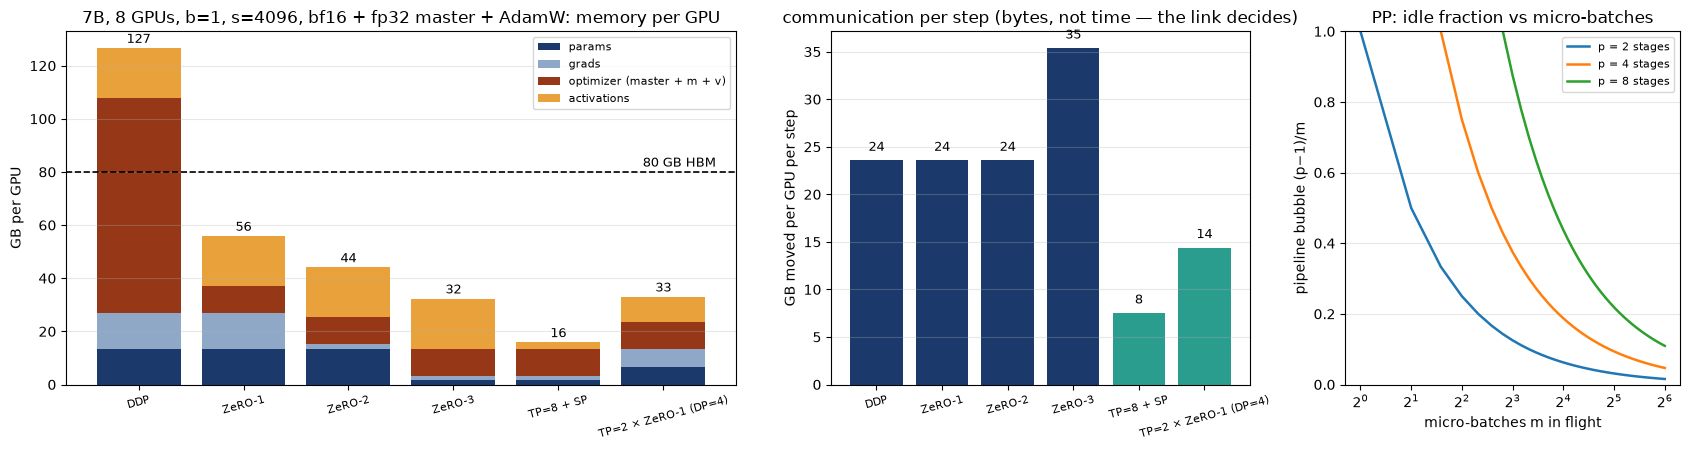

→ out\04_parallelism.png


In [38]:
fig, ax = plt.subplots(1, 3, figsize=(17, 4.6), gridspec_kw={"width_ratios": [1.6, 1, 0.8]})
names = [lay["layout"] for lay in LAYOUTS]
colors = {"params": "#1b3a6b", "grads": "#8fa8c8", "optimizer (master + m + v)": "#963817", "activations": "#e9a23b"}
bottom = [0.0] * len(LAYOUTS)
for key in colors:
    vals = [lay["mem"][key] / GB for lay in LAYOUTS]
    ax[0].bar(names, vals, bottom=bottom, color=colors[key], label=key)
    bottom = [b + v for b, v in zip(bottom, vals)]
ax[0].axhline(HBM / GB, ls="--", c="k", lw=1.2); ax[0].text(len(LAYOUTS) - 0.5, HBM / GB + 2, "80 GB HBM", ha="right", fontsize=9)
for i, tot in enumerate(bottom):
    ax[0].text(i, tot + 2, f"{tot:.0f}", ha="center", fontsize=9)
ax[0].set_ylabel("GB per GPU"); ax[0].set_title("7B, 8 GPUs, b=1, s=4096, bf16 + fp32 master + AdamW: memory per GPU")
ax[0].tick_params(axis="x", labelsize=8, rotation=15); ax[0].legend(fontsize=8)

ax[1].bar(names, [lay["comm"] / GB for lay in LAYOUTS], color=["#1b3a6b"] * 4 + ["#2a9d8f", "#2a9d8f"])
ax[1].set_ylabel("GB moved per GPU per step"); ax[1].set_title("communication per step (bytes, not time — the link decides)")
ax[1].tick_params(axis="x", labelsize=8, rotation=15)
for i, lay in enumerate(LAYOUTS):
    ax[1].text(i, lay["comm"] / GB + 1, f"{lay['comm'] / GB:.0f}", ha="center", fontsize=9)

ms = list(range(1, 65))
for p in (2, 4, 8):
    ax[2].plot(ms, [(p - 1) / m for m in ms], lw=1.8, label=f"p = {p} stages")
ax[2].set_xscale("log", base=2); ax[2].set_ylim(0, 1); ax[2].set_xlabel("micro-batches m in flight"); ax[2].set_ylabel("pipeline bubble (p−1)/m")
ax[2].set_title("PP: idle fraction vs micro-batches"); ax[2].legend(fontsize=8)
for a in ax:
    a.grid(axis="y", alpha=.3)
fig.tight_layout(); fig.savefig(OUT / "04_parallelism.png", dpi=140)
plt.show()
print(f"→ {OUT / '04_parallelism.png'}")

## 6. The decision tree

```
does not fit → activations?      → recompute / smaller micro-batch / CP if it is the length
             → optimizer state?  → ZeRO-1  (free)  → ZeRO-2 → ZeRO-3
             → a single layer?   → TP inside the node, always with SP
             → depth?            → PP between nodes
too slow     → exposed comm?     → overlap, bigger buckets, move the axis to the faster link
             → bubble?           → more micro-batches, 1F1B / interleaved / zero-bubble
             → memory-bound ops? → fusion, precision, custom kernels
```

---

# 05 — the optimizer's state: what it costs, and two ways to make it smaller

With ZeRO-1 (section 04) the optimizer state is split across the data-parallel ranks with no
extra communication and no effect on quality. The state of a 7B model on 8 GPUs is then 10 GB
per GPU, and activations take more memory. This section shows when it is still worth making the
state itself smaller, and compares two ways of doing it:

1. **the state map** — bytes per parameter for each optimizer, and what 4 bytes per parameter
   amount to at 1B, 70B and 1.6T parameters, before and after ZeRO-1;
2. **the distribution of `v`** — Adam's second moment spans many orders of magnitude and is
   used as a denominator;
3. **compression**: `m` and `v` kept in int8 between steps, per tensor, per block, and per block
   in square-root space;
4. **sharing**: Adam-mini keeps one `v` per attention head or per row instead of one per
   coordinate;
5. **sharding**: Adam-mini's blocks split across ranks;
6. the same recipes on a 160M model on a GPU, recorded in advance.

Runtime ~3 min on CPU. Dependencies: `torch`, `matplotlib`.

Sources: Dettmers et al., *8-bit Optimizers via Block-wise Quantization*
([2110.02861](https://arxiv.org/abs/2110.02861)) · Zhang et al., *Adam-mini: Use Fewer Learning
Rates To Gain More* ([2406.16793](https://arxiv.org/abs/2406.16793)).

In [39]:
from __future__ import annotations

import json
import os
import math
import sys
import time
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

if hasattr(sys.stdout, "reconfigure"):
    sys.stdout.reconfigure(encoding="utf-8", errors="replace")
torch.manual_seed(0)
torch.set_num_threads(max(1, (os.cpu_count() or 2) // 2))       # half the cores; idempotent when sections run in one kernel

OUT = Path("out")
OUT.mkdir(exist_ok=True)

STEPS, BATCH, LR, WD, BLOCK = 300, 16, 3e-4, 0.1, 256

## 1. The state map

Optimizers differ in how many buffers per parameter they keep. Adam stores its per-coordinate
scaling (`v`, one number per coordinate), Muon computes its normalization every step from the
whole matrix, and Lion and SGD have no such scaling. The second table shows what removing one
fp32 buffer (4 bytes per parameter) saves, in total and per GPU after ZeRO-1 over 64
data-parallel ranks.

In [40]:
STATE = {"SGD": 0, "SGD + momentum": 4, "Lion": 4, "AdamW": 8, "AdamW, int8 state": 2,
         "Adam-mini": 4, "Muon (matrices)": 4, "AdEMAMix": 12}
print(f"{'optimizer':<20}{'bytes/param':>12}")
for k, b in STATE.items():
    print(f"{k:<20}{b:>12}")

DP = 64
print(f"\nwhat 4 bytes per parameter are worth:")
print(f"{'model':<8}{'total':>9}{'of one 80 GB GPU':>18}{f'per GPU after ZeRO-1 over {DP}':>31}")
for name, n_params in (("1B", 1e9), ("70B", 70e9), ("1.6T", 1.6e12)):
    saved = 4 * n_params
    print(f"{name:<8}{saved / 1e9:>7.0f}GB{100 * saved / 80e9:>17.0f}%{saved / DP / 1e9:>28.2f} GB")

optimizer            bytes/param
SGD                            0
SGD + momentum                 4
Lion                           4
AdamW                          8
AdamW, int8 state              2
Adam-mini                      4
Muon (matrices)                4
AdEMAMix                      12

what 4 bytes per parameter are worth:
model       total  of one 80 GB GPU   per GPU after ZeRO-1 over 64
1B            4GB                5%                        0.06 GB
70B         280GB              350%                        4.38 GB
1.6T       6400GB             8000%                      100.00 GB


At 1B the saving is 4 GB in total and 60 MB per GPU with ZeRO-1, which is negligible. At 70B it
is 4 GB per GPU, a few percent of the card. At 1.6T it is **100 GB per GPU even after sharding
over 64 ranks**, more than a whole H100. Reducing optimizer state matters for **fitting very
large models, not for convergence**, and mostly when the data-parallel degree cannot grow further
(it is limited by the critical batch size).

## 2. The distribution of `v`

The model is the same small GPT as in the other sections; the task is a random Markov chain over
64 symbols, so the loss has a known floor (its entropy). After three hundred AdamW steps in fp32
we look at the histogram of `v`. If `v` were stored in int8 with one linear scale per tensor, the
smallest non-zero level would be `max(v)/127`, and entries below half of that would round to
exactly zero. The cell computes their fraction.

In [41]:
@dataclass
class Cfg:
    vocab: int = 64
    block: int = 64
    n_layer: int = 4
    n_head: int = 4
    n_embd: int = 128
    d_ff: int = 384


def norm(x):
    return F.rms_norm(x, (x.size(-1),))


class Attention(nn.Module):
    def __init__(self, c: Cfg):
        super().__init__()
        self.nh, self.dh = c.n_head, c.n_embd // c.n_head
        self.q, self.k, self.v, self.o = (nn.Linear(c.n_embd, c.n_embd, bias=False) for _ in range(4))

    def forward(self, x):
        B, T, C = x.shape
        q, k, v = (proj(x).view(B, T, self.nh, self.dh).transpose(1, 2) for proj in (self.q, self.k, self.v))
        y = F.scaled_dot_product_attention(q, k, v, is_causal=True)
        return self.o(y.transpose(1, 2).reshape(B, T, C))


class MLP(nn.Module):
    def __init__(self, c: Cfg):
        super().__init__()
        self.gate, self.up = nn.Linear(c.n_embd, c.d_ff, bias=False), nn.Linear(c.n_embd, c.d_ff, bias=False)
        self.down = nn.Linear(c.d_ff, c.n_embd, bias=False)

    def forward(self, x):
        return self.down(F.silu(self.gate(x)) * self.up(x))


class Block(nn.Module):
    def __init__(self, c: Cfg):
        super().__init__()
        self.attn, self.mlp = Attention(c), MLP(c)

    def forward(self, x):
        x = x + self.attn(norm(x))
        return x + self.mlp(norm(x))


class GPT(nn.Module):
    def __init__(self, c: Cfg):
        super().__init__()
        self.c = c
        self.wte = nn.Embedding(c.vocab, c.n_embd)
        self.blocks = nn.ModuleList(Block(c) for _ in range(c.n_layer))
        self.head = nn.Linear(c.n_embd, c.vocab, bias=False)

    def forward(self, idx, targets=None):
        x = norm(self.wte(idx))
        for b in self.blocks:
            x = b(x)
        logits = self.head(norm(x))
        if targets is None:
            return logits, None
        return logits, F.cross_entropy(logits.view(-1, self.c.vocab), targets.reshape(-1))


class MarkovTask:
    def __init__(self, vocab=64, fanout=4, seed=1):
        g = torch.Generator().manual_seed(seed)
        P = torch.zeros(vocab, vocab)
        for s in range(vocab):
            P[s, torch.randperm(vocab, generator=g)[:fanout]] = torch.rand(fanout, generator=g) + 0.2
        self.P, self.vocab, self.g = P / P.sum(-1, keepdim=True), vocab, g
        self.floor = (-(self.P * torch.log(self.P.clamp_min(1e-12))).sum(-1)).mean().item()

    def batch(self, B, T):
        seq = torch.empty(B, T + 1, dtype=torch.long)
        seq[:, 0] = torch.randint(0, self.vocab, (B,), generator=self.g)
        for t in range(T):
            seq[:, t + 1] = torch.multinomial(self.P[seq[:, t]], 1, generator=self.g).squeeze(1)
        return seq[:, :-1], seq[:, 1:]


cfg = Cfg()
task = MarkovTask(cfg.vocab)


def train_fp32_reference(steps=STEPS):
    torch.manual_seed(0)
    task = MarkovTask(cfg.vocab, seed=1)
    model = GPT(cfg)
    opt = torch.optim.AdamW(model.parameters(), lr=LR, betas=(0.9, 0.95), weight_decay=WD)
    for _ in range(steps):
        x, y = task.batch(BATCH, cfg.block)
        _, loss = model(x, y)
        loss.backward()
        opt.step(); opt.zero_grad(set_to_none=True)
    return model, opt


ref_model, ref_opt = train_fp32_reference()
v_all = torch.cat([ref_opt.state[p]["exp_avg_sq"].reshape(-1) for p in ref_model.parameters()])
m_all = torch.cat([ref_opt.state[p]["exp_avg"].reshape(-1) for p in ref_model.parameters()])
v_pos = v_all[v_all > 0]
print(f"v after {STEPS} steps: min {v_pos.min():.1e}, median {v_pos.median():.1e}, max {v_pos.max():.1e} — "
      f"{math.log10(v_pos.max() / v_pos.min()):.0f} orders of magnitude in one optimizer")
print(f"the same for m: |m| spans {math.log10(m_all.abs().max() / m_all.abs()[m_all != 0].min()):.0f} orders, "
      f"but m is a signed average, not a denominator")

# v relative to the largest entry of ITS OWN tensor — that is what a per-tensor scale sees
v_rel = torch.cat([(ref_opt.state[p]["exp_avg_sq"] / ref_opt.state[p]["exp_avg_sq"].max()).reshape(-1)
                   for p in ref_model.parameters()])
zero_level = 1 / 127 / 2                                  # below half the smallest level, round-to-nearest gives 0
frac_zero = (v_rel < zero_level).float().mean().item()
print(f"\nint8 with one linear scale per tensor: {100 * frac_zero:.1f}% of all v entries would round to ZERO — "
      f"and 1/(√0 + 1e-8) = 1e8")

v after 300 steps: min 1.9e-10, median 4.8e-08, max 2.9e-04 — 6 orders of magnitude in one optimizer
the same for m: |m| spans 8 orders, but m is a signed average, not a denominator

int8 with one linear scale per tensor: 0.8% of all v entries would round to ZERO — and 1/(√0 + 1e-8) = 1e8


A per-tensor linear grid gives 127 levels to the range near the largest entry of each tensor and
none to its smallest entries. A percent or two of the coordinates is not much, but these
coordinates receive updates `1e8` times too large, which is enough to make training diverge.

Two properties make `v` particularly hard to quantize:

* it is used through `1/√v`. That function is nearly flat where `v` is large and vertical where
  `v` is small, so the same absolute rounding error is harmless at one end and catastrophic at
  the other;
* it is an exponential moving average, so an error written into it persists for about
  `1/(1−β₂)` steps, and quantization errors accumulate.

## 3. Compression: the state in int8 between steps

Three ways to put a tensor into int8 and bring it back:

* **per-tensor, linear** — `q = round(x / s)`, `s = max|x| / 127`, one `s` for everything;
* **block-wise, linear** — the same with one `s` per block of 256 consecutive entries. The scales
  are the price: one float per block, 4/256 of a byte per entry;
* **block-wise in √-space** — quantize `√v` instead of `v` and square it when dequantizing. The
  square root moves small values up the grid: a `v` at `1e-4·max` is at `1e-2·max` in √-space
  and gets nonzero levels. This is a simple substitute for the non-linear "dynamic" map used by
  8-bit Adam; both put more levels where most of the values are.

The state lives in int8 *between* steps: unpack → update in fp32 → pack.

In [42]:
def quantize_per_tensor(x):
    s = x.abs().max().clamp_min(1e-30) / 127
    return torch.round(x / s).to(torch.int8), s


def dequantize_per_tensor(q, s):
    return q.float() * s


def quantize_blockwise(x, block=BLOCK):
    """int8 codes and one fp32 scale per block of `block` consecutive entries."""
    flat = x.reshape(-1)
    pad = (-flat.numel()) % block
    if pad:
        flat = torch.cat([flat, torch.zeros(pad)])
    blocks = flat.view(-1, block)
    s = blocks.abs().amax(dim=1, keepdim=True).clamp_min(1e-30) / 127
    q = torch.round(blocks / s).to(torch.int8)
    return q, s.squeeze(1)


def dequantize_blockwise(q, s, shape):
    flat = (q.float() * s[:, None]).reshape(-1)
    return flat[:math.prod(shape)].view(shape)


class QuantState:
    """One optimizer buffer kept between steps. `mode`: 'fp32' | 'tensor' | 'block' | 'block_sqrt'."""
    def __init__(self, like, mode):
        self.mode, self.shape = mode, like.shape
        self.set(torch.zeros_like(like))

    def set(self, x):
        if self.mode == "fp32":
            self.x = x.clone()
        elif self.mode == "tensor":
            self.q, self.s = quantize_per_tensor(x)
        elif self.mode == "block":
            self.q, self.s = quantize_blockwise(x)
        elif self.mode == "block_sqrt":
            self.q, self.s = quantize_blockwise(x.clamp_min(0).sqrt())

    def get(self):
        if self.mode == "fp32":
            return self.x
        if self.mode == "tensor":
            return dequantize_per_tensor(self.q, self.s).view(self.shape)
        x = dequantize_blockwise(self.q, self.s, self.shape)
        return x * x if self.mode == "block_sqrt" else x

    def nbytes(self):
        if self.mode == "fp32":
            return self.x.numel() * 4
        return self.q.numel() + self.s.numel() * 4


class QuantAdamW:
    """AdamW whose m and v live in QuantState between steps: dequantize → update → requantize."""
    def __init__(self, model, m_mode, v_mode, lr=LR, betas=(0.9, 0.95), wd=WD, eps=1e-8):
        self.params, self.lr, self.b1, self.b2, self.wd, self.eps, self.t = list(model.parameters()), lr, *betas, wd, eps, 0
        self.m = [QuantState(p, m_mode) for p in self.params]
        self.v = [QuantState(p, v_mode) for p in self.params]

    @torch.no_grad()
    def step(self):
        self.t += 1
        for p, ms, vs in zip(self.params, self.m, self.v):
            m, v = ms.get(), vs.get()                                   # round-trip 1: unpack
            m.mul_(self.b1).add_(p.grad, alpha=1 - self.b1)
            v.mul_(self.b2).addcmul_(p.grad, p.grad, value=1 - self.b2)
            upd = (m / (1 - self.b1 ** self.t)) / ((v / (1 - self.b2 ** self.t)).sqrt() + self.eps)
            p.mul_(1 - self.lr * self.wd).add_(upd, alpha=-self.lr)
            ms.set(m); vs.set(v)                                        # round-trip 2: pack
            p.grad = None

    def state_bytes(self):
        return sum(s.nbytes() for s in self.m + self.v)

## 4. Sharing: Adam-mini

Another way to make `v` smaller is to store **fewer values** instead of storing them at lower
precision. `v` acts as a per-coordinate learning rate. Adam-mini's claim is that most of these
learning rates are redundant: the Hessian of a transformer is close to block-diagonal, with
blocks that follow the architecture, and inside one block a single learning rate works as well
as a separate one per coordinate. The blocks:

* `q` and `k`: **one `v` per attention head** — the rows of that head;
* every other matrix (`v`, `o`, the MLP, the embedding, the head): **one `v` per row** — per
  output neuron, per token for the embedding;
* the value of that one `v` is the running mean of `g²` over the block.

The first moment `m` stays full-size, so the state goes from 8 bytes per parameter to a little
over 4. The update is still *almost* element-wise: it needs only the mean of `g²` over one row
or one head (this matters for sharding, section 6).

In [43]:
class AdamMini:
    """Adam with one second moment per block: per head for q and k, per row for every other matrix."""
    def __init__(self, model, lr=LR, betas=(0.9, 0.95), wd=WD, eps=1e-8):
        self.lr, self.b1, self.b2, self.wd, self.eps, self.t = lr, *betas, wd, eps, 0
        self.items = []
        for name, p in model.named_parameters():
            rows = model.c.n_head if name.endswith(("attn.q.weight", "attn.k.weight")) else p.shape[0]
            self.items.append((p, rows, torch.zeros_like(p), torch.zeros(rows, 1)))

    @torch.no_grad()
    def step(self):
        self.t += 1
        for p, rows, m, v in self.items:
            g = p.grad
            m.mul_(self.b1).add_(g, alpha=1 - self.b1)
            v.mul_(self.b2).add_(g.view(rows, -1).pow(2).mean(dim=1, keepdim=True), alpha=1 - self.b2)
            upd = (m.view(rows, -1) / (1 - self.b1 ** self.t)) / ((v / (1 - self.b2 ** self.t)).sqrt() + self.eps)
            p.mul_(1 - self.lr * self.wd).add_(upd.view_as(p), alpha=-self.lr)
            p.grad = None

    def state_bytes(self):
        return sum(m.numel() * 4 + v.numel() * 4 for _, _, m, v in self.items)


mini = AdamMini(GPT(cfg))
n_v = sum(v.numel() for *_, v in mini.items)
n_p = sum(p.numel() for p, *_ in mini.items)
print(f"Adam-mini on this model: {n_v:,} second-moment entries for {n_p:,} parameters "
      f"({100 * n_v / n_p:.2f}%); state {mini.state_bytes() / n_p:.2f} B/param against AdamW's 8")

Adam-mini on this model: 4,768 second-moment entries for 868,352 parameters (0.55%); state 4.02 B/param against AdamW's 8


## 5. Six recipes, one task

Same model, same task, same seed and batches, 300 steps, learning rate `3e-4` for all:
fp32 state; `m` alone in int8; `m` and `v` in int8 per tensor; per block of 256; per block with
`v` in √-space (the 8-bit Adam recipe); and Adam-mini. Step time is the median wall-clock of
`optimizer.step()` on this CPU; only the ratios between rows are meaningful.

In [44]:
RECIPES = {
    "fp32 state": lambda m: QuantAdamW(m, "fp32", "fp32"),
    "int8 m only, per-tensor": lambda m: QuantAdamW(m, "tensor", "fp32"),
    "int8 m+v, per-tensor": lambda m: QuantAdamW(m, "tensor", "tensor"),
    "int8 m+v, block-wise 256": lambda m: QuantAdamW(m, "block", "block"),
    "int8 m+v, block-wise, v in √-space": lambda m: QuantAdamW(m, "block", "block_sqrt"),
    "Adam-mini": lambda m: AdamMini(m),
}


def train(make_opt, steps=STEPS):
    torch.manual_seed(0)
    task = MarkovTask(cfg.vocab, seed=1)
    model = GPT(cfg)
    opt = make_opt(model)
    losses, ms = [], []
    for _ in range(steps):
        x, y = task.batch(BATCH, cfg.block)
        _, loss = model(x, y)
        loss.backward()
        t0 = time.perf_counter(); opt.step(); ms.append((time.perf_counter() - t0) * 1e3)
        losses.append(loss.item() if math.isfinite(loss.item()) else float("nan"))
    ms.sort()
    n = sum(p.numel() for p in model.parameters())
    return losses, ms[len(ms) // 2], opt.state_bytes() / n


results = {}
print(f"{'recipe':<38}{'final loss':>11}{'(floor)':>9}{'worst loss':>11}{'state B/param':>15}{'step ms':>9}")
for name, make in RECIPES.items():
    losses, step_ms, bpp = train(make)
    results[name] = (losses, step_ms, bpp)
    finite = [l for l in losses if math.isfinite(l)]
    tail = sum(losses[-20:]) / 20
    print(f"{name:<38}{tail:>11.3f}{task.floor:>9.3f}{max(finite):>11.2f}{bpp:>15.2f}{step_ms:>9.1f}")

recipe                                 final loss  (floor) worst loss  state B/param  step ms


fp32 state                                  1.383    1.306       4.31           8.00      7.6


int8 m only, per-tensor                     1.383    1.306       4.31           5.00     12.5


int8 m+v, per-tensor                     2236.286    1.306    3246.18           2.00     21.3


int8 m+v, block-wise 256                   34.233    1.306      63.62           2.03     24.8


int8 m+v, block-wise, v in √-space          1.383    1.306       4.31           2.03     26.1


Adam-mini                                   1.376    1.306       4.31           4.02      6.9


In the `worst loss` column, fp32 and the `m`-only recipe never go above their starting loss: the
first moment is a signed average, an 8-bit error in it is a small error in the direction of one
step, and momentum smooths it out. When `v` is put on the same per-tensor grid, the run diverges
(loss in the thousands) by the mechanism predicted in section 2 from the histogram: coordinates
whose `v` rounded to zero receive updates eight orders of magnitude too large.

Block-wise scales alone are not enough. Every block of 256 has its own maximum, so fewer
coordinates are zeroed, but a block of `v` still spans several orders of magnitude, its small
entries still round to zero, and the run still diverges, only later. Quantizing `v` in √-space
fixes it: the grid is then closer to uniform in the quantity the optimizer divides by. Block
scales together with a non-linear map are the 8-bit Adam recipe: 2 bytes of state per parameter
instead of 8, with the same final loss as fp32 to three decimals.

Adam-mini reaches the same result differently: it keeps half a percent of the `v` entries, in full
precision, and trains as well as fp32 AdamW on this task. This is one small task; the paper
reports the same parity from 39M to 13B parameters.

In the `step ms` column (only ratios are meaningful), the int8 recipes are **slower** per step
than fp32: unpacking and packing each buffer on every step are extra memory-bound passes on top
of AdamW's, which are memory-bound already. Fused GPU kernels reduce this overhead (section 7)
but do not remove it. Adam-mini costs about the same as AdamW here: one mean per row instead of
one square root per coordinate.

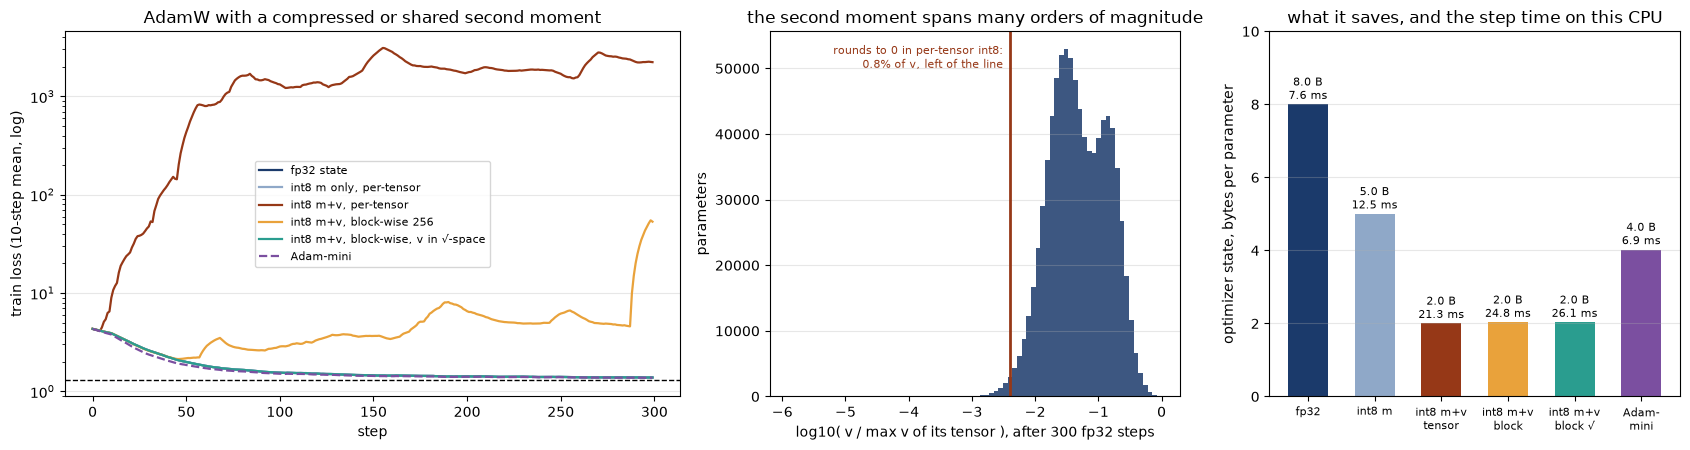

→ out\05_optimizer_state.png


In [45]:
fig, ax = plt.subplots(1, 3, figsize=(17, 4.6), gridspec_kw={"width_ratios": [1.5, 1, 1]})
colors = ["#1b3a6b", "#8fa8c8", "#963817", "#e9a23b", "#2a9d8f", "#7b4fa0"]
for (name, (losses, _, _)), c in zip(results.items(), colors):
    k = 10
    smooth = [sum(losses[max(0, i - k):i + 1]) / len(losses[max(0, i - k):i + 1]) for i in range(len(losses))]
    ax[0].plot(smooth, label=name, color=c, lw=1.6, ls="--" if name == "Adam-mini" else "-")
ax[0].axhline(task.floor, ls="--", c="k", lw=1)
ax[0].set_yscale("log"); ax[0].set_xlabel("step"); ax[0].set_ylabel("train loss (10-step mean, log)")
ax[0].set_title("AdamW with a compressed or shared second moment"); ax[0].legend(fontsize=8)

logv = torch.log10(v_rel[v_rel > 0])
ax[1].hist(logv.numpy(), bins=80, color="#1b3a6b", alpha=.85)
ax[1].axvline(math.log10(zero_level), color="#963817", lw=2)
ax[1].text(math.log10(zero_level) - 0.1, ax[1].get_ylim()[1] * 0.9,
           f"rounds to 0 in per-tensor int8:\n{100 * frac_zero:.1f}% of v, left of the line", fontsize=8, color="#963817", ha="right")
ax[1].set_xlabel("log10( v / max v of its tensor ), after 300 fp32 steps"); ax[1].set_ylabel("parameters")
ax[1].set_title("the second moment spans many orders of magnitude")

names = list(results)
bpp = [results[n][2] for n in names]
stp = [results[n][1] for n in names]
ax[2].bar(range(len(names)), bpp, color=colors, width=0.6)
for i, (b, s) in enumerate(zip(bpp, stp)):
    ax[2].text(i, b + 0.15, f"{b:.1f} B\n{s:.1f} ms", ha="center", fontsize=8)
ax[2].set_xticks(range(len(names)))
ax[2].set_xticklabels(["fp32", "int8 m", "int8 m+v\ntensor", "int8 m+v\nblock", "int8 m+v\nblock √", "Adam-\nmini"], fontsize=8)
ax[2].set_ylabel("optimizer state, bytes per parameter"); ax[2].set_title("what it saves, and the step time on this CPU")
ax[2].set_ylim(0, 10)
for a in ax:
    a.grid(axis="y", alpha=.3)
fig.tight_layout(); fig.savefig(OUT / "05_optimizer_state.png", dpi=140)
plt.show()
print(f"→ {OUT / '05_optimizer_state.png'}")

## 6. Adam-mini under sharding

Under ZeRO-1 each rank holds a slice of every parameter and updates only that slice. For AdamW
the way the slices are cut does not matter: its update of coordinate `i` reads only `g_i, m_i,
v_i`. Adam-mini needs the mean of `g²` over a row or a head. If a shard boundary cuts through a
block, the ranks holding the two parts must add their partial sums of `g²` before either can
take its step: one number per straddling block. Below, one `q` gradient (4 heads of 32 rows) and
one MLP gradient are row-sharded over 4 ranks and over 3, and we count the bytes each rank has to
send to compute Adam-mini's `v` exactly.

In [46]:
def adam_mini_v_sharded(G, n_ranks, rows_per_block):
    """Adam-mini's block means of g², computed from row shards. Returns the blocks' values and the
    number of blocks that straddle a shard boundary (each needs one scalar all-reduce)."""
    n_rows = G.size(0)
    bounds = [round(r * n_rows / n_ranks) for r in range(n_ranks + 1)]
    sums, straddling = torch.zeros(n_rows // rows_per_block), 0
    for r in range(n_ranks):                         # each rank sees only its own rows
        lo, hi = bounds[r], bounds[r + 1]
        for row in range(lo, hi):
            sums[row // rows_per_block] += G[row].pow(2).sum()
    for b in range(n_rows // rows_per_block):
        first, last = b * rows_per_block, (b + 1) * rows_per_block - 1
        owner = lambda row: max(r for r in range(n_ranks) if bounds[r] <= row)
        straddling += owner(first) != owner(last)
    return sums / (rows_per_block * G.size(1)), straddling


torch.manual_seed(2)
G_q, G_up = torch.randn(128, 128), torch.randn(384, 128)
print(f"{'gradient':<22}{'ranks':>6}{'blocks':>8}{'straddling':>12}{'extra bytes/rank':>18}{'exact?':>8}")
for label, G, rows_per_block in (("q, one v per head", G_q, 32), ("MLP up, one v per row", G_up, 1)):
    ref = G.view(G.size(0) // rows_per_block, -1).pow(2).mean(dim=1)
    for n_ranks in (4, 3):
        v, straddling = adam_mini_v_sharded(G, n_ranks, rows_per_block)
        print(f"{label:<22}{n_ranks:>6}{len(v):>8}{straddling:>12}{2 * 4 * straddling / n_ranks:>17.1f}B"
              f"{str(torch.allclose(v, ref)):>8}")
print(f"\nfor comparison, gathering the whole {G_up.shape[0]}×{G_up.shape[1]} matrix on every rank "
      f"(what an optimizer that needs the full matrix must do): {3 / 4 * G_up.numel() * 4 / 1e3:.0f} KB per rank")

gradient               ranks  blocks  straddling  extra bytes/rank  exact?
q, one v per head          4       4           0              0.0B    True
q, one v per head          3       4           2              5.3B    True
MLP up, one v per row      4     384           0              0.0B    True
MLP up, one v per row      3     384           0              0.0B    True

for comparison, gathering the whole 384×128 matrix on every rank (what an optimizer that needs the full matrix must do): 147 KB per rank


When the shard boundaries fall between blocks (4 heads on 4 ranks, or any number of ranks for
per-row blocks), Adam-mini on a shard is exactly Adam-mini on the whole matrix, with no extra
bytes. When a boundary cuts a head in two (4 heads on 3 ranks), two partial sums have to be
combined: a few bytes per straddling block, compared with hundreds of kilobytes to gather the
whole matrix. The Adam-mini implementation does this: blocks inside one shard are updated
locally, and each of the others costs one scalar `all_reduce`. **Sharding stays almost free.**
For optimizers that need the whole matrix, such as Muon, it does not: the last printed number is
the cost of the simplest option, gathering the matrix on every rank.

## 7. The same recipes at 160M parameters, on a GPU

Recorded in advance with `gpu/train_optimizers.py`: a 12-layer GPT with `d = 768` and the GPT-2
vocabulary (160M parameters), 2 500 steps of 16k tokens of FineWeb-Edu, the same learning rate
`6e-4` and schedule for every run, fp32 master weights with bf16 autocast, on one A100. Peak
memory is `torch.cuda.max_memory_allocated`; step times are medians over CUDA events.

NVIDIA A100-SXM4-80GB, torch 2.11.0+cu128; 12L d768, vocab 50304, seq 1024, 16384 tokens/step, 2500 steps, FineWeb-Edu sample-10BT, GPT-2 tokenizer

run                                          val loss  state B/param  peak GB  opt ms  step ms
AdamW, fp32 state                               4.668           8.00     7.22     2.9      155
AdamW, int8 m+v, per-tensor                 diverged @11           2.00     6.26    43.7      212
AdamW, int8 m+v, block 256                  diverged @81           2.03     6.27    44.9      216
AdamW, int8 m+v, block 256, v in √-space        4.668           2.03     6.27    45.4      205
bitsandbytes AdamW8bit                          4.669           2.03     6.25    19.6      176
Adam-mini                                       4.708           4.00     6.58     9.5      178


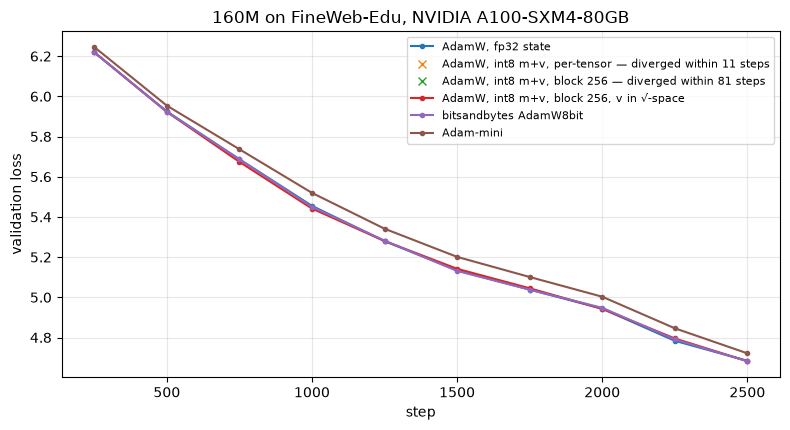

In [47]:
gpu_path = OUT / "gpu_train_optimizers.json"
gpu = json.loads(gpu_path.read_text()) if gpu_path.exists() else None
STATE_RUNS = ["adamw", "int8_tensor", "int8_block", "int8_block_sqrt", "bnb_adamw8bit", "adam_mini"]
if gpu:
    print(f"{gpu['env']['gpu']}, torch {gpu['env']['torch']}; {gpu['setup']['model']}, "
          f"{gpu['setup']['tokens_per_step']} tokens/step, {gpu['setup']['steps']} steps, {gpu['setup']['data']}\n")
    print(f"{'run':<44}{'val loss':>9}{'state B/param':>15}{'peak GB':>9}{'opt ms':>8}{'step ms':>9}")
    for key in STATE_RUNS:
        r = gpu["runs"].get(key)
        if r is None:
            continue
        val = f"{r['final_val']:.3f}" if not r["diverged"] else f"diverged @{r['steps_done']}"
        print(f"{r['label']:<44}{val:>9}{r['state_bytes_per_param']:>15.2f}{r['peak_mem_gb']:>9.2f}"
              f"{r['opt_step_ms']:>8.1f}{r['full_step_ms']:>9.0f}")
    fig, ax = plt.subplots(figsize=(8, 4.4))
    for i, key in enumerate(k for k in STATE_RUNS if k in gpu["runs"]):
        r = gpu["runs"][key]
        if r["diverged"]:                           # no evaluation happened: show where it stopped
            ax.plot([], [], "x", color=f"C{i}", label=f"{r['label']} — diverged within {r['steps_done']} steps")
            continue
        steps, vals = zip(*r["val_loss"])
        ax.plot(steps, vals, "o-", ms=3, label=r["label"], color=f"C{i}")
    ax.set_xlabel("step"); ax.set_ylabel("validation loss"); ax.grid(alpha=.3); ax.legend(fontsize=8)
    ax.set_title(f"160M on FineWeb-Edu, {gpu['env']['gpu']}")
    fig.tight_layout(); fig.savefig(OUT / "05_gpu_state.png", dpi=140)
    plt.show()
else:
    print("no out/gpu_train_optimizers.json — run gpu/train_optimizers.py on a machine with a GPU")

Observations:

* **The toy results hold at 160M, and the failures happen faster.** Per-tensor int8 diverges
  within 11 steps, block-wise linear int8 within 81. With `v` in √-space the run ends at
  validation loss 4.668, the same as fp32 AdamW to three decimals, and so does bitsandbytes'
  8-bit AdamW (4.669), which uses its own non-linear map. Every int8 recipe behaves at 160M as
  it did on the toy task.
* **Adam-mini is slightly behind**: 4.708 against 4.668, with the learning rate tuned for neither.
  At 160M and 41M tokens the gap is small; the paper tunes the learning rate and reports parity.
  This ranking should not be quoted without a learning-rate sweep.
* **State bytes against peak memory.** Going from 8 to 2 bytes of state saves 6 bytes per
  parameter, about 1 GB at 160M, and the peak drops from 7.22 to 6.27 GB, by that amount. The rest
  of the peak is weights, gradients and activations, which the optimizer does not affect. At 160M
  on one GPU the state is not the main item, and compressing it saves 13%, as section 1 predicts.
* **Step time.** Fused AdamW takes 2.9 ms. The same 8-bit recipe in plain PyTorch takes 45 ms, and
  bitsandbytes' fused CUDA kernels 20 ms. Our Adam-mini, also plain PyTorch, takes 9.5 ms. The full
  step grows from 155 ms to 205, 176 and 178 ms: +32%, +14% and +15%. Compressed state costs time
  even with good kernels: it is quantized to save space, not to speed things up.

## 8. What to try when a run does not fit

1. **ZeRO-1.** No extra communication, no effect on quality, divides the optimizer state by the
   DP degree.
2. **Recompute and lower-precision activations**, since activations take most of the memory
   (sections 01, 04).
3. **An optimizer with less state**, such as Adam-mini (4 bytes instead of 8). This helps fit
   larger models and does not improve convergence. Adam-mini keeps sharding almost free.
4. **Quantized state**, last: block-wise, non-linear for `v`, and with a slower step, because
   every buffer is unpacked and packed again on every step.

In general, **optimizer buffers without a second moment are easy to keep in low precision, and
slowly accumulated second moments are the hardest.** A momentum buffer quantizes like `m` did
here, without harm. Adam's `v` is used as a denominator and remembered for `1/(1−β₂)` steps, which
makes it the hardest case.